# Qwen3-14B retail: SFT training + rejection-sampling rollouts

**Section 1** is the single-turn ground-truth-distillation SFT run (500 retail train tasks, instruction dumped upfront as one user message). This training converged cleanly (final loss 0.4724) but **caused a catastrophic eval regression (0.452 -> 0.026 avg reward)** -- the model learned to fire tool calls immediately on any user message instead of gathering info across turns, since every training example had the complete request available upfront. Kept here as a documented negative result, not reused.

**Section 2** is the fix: real multi-turn rollouts, generated by running the actual base (non-fine-tuned) model against the real τ-bench env + GPT-4o user-simulator, up to 2 tries per train task, keeping only genuinely passing (reward=1.0) trajectories as new SFT data.

## Section 1: single-turn SFT run (abandoned)

37 logged steps, latest loss = 0.4139 at epoch 2.94


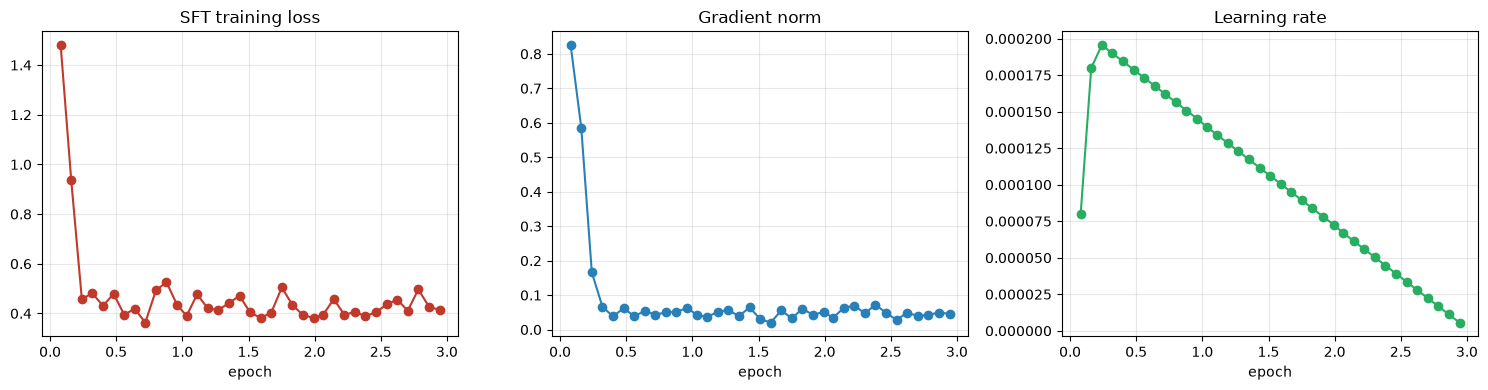

In [4]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_train_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("SFT training loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 2: rejection-sampling rollout generation (current, in progress)

500/500 tasks done, 422 passed, 78 skipped, cost so far $1.41


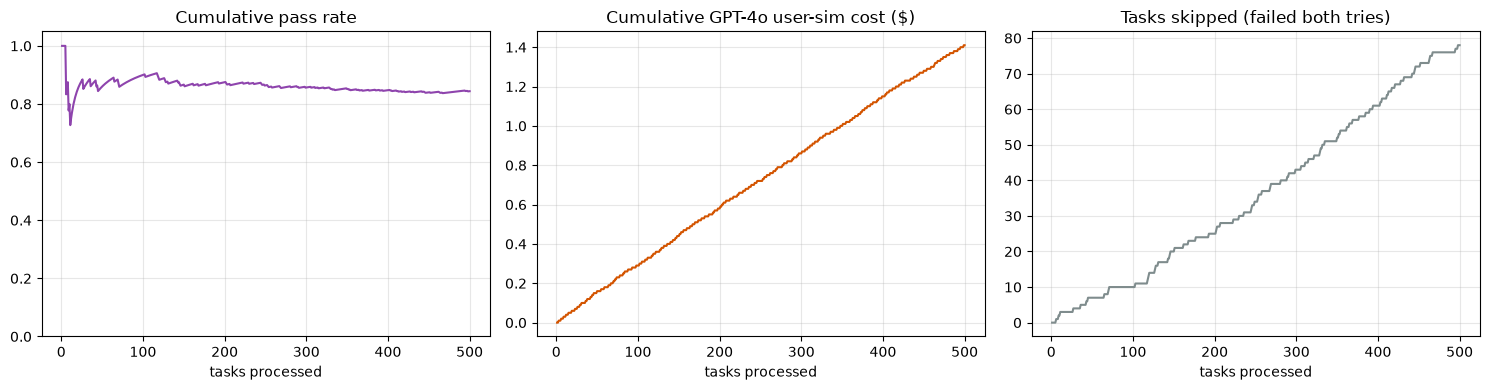

In [5]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/rollout_progress.json"))
if not records:
    print("no rollout progress data yet -- job may have just (re)started, try again in a few minutes")
else:
    task = [r["task"] for r in records]
    pass_rate = [r["passed"] / r["task"] for r in records]
    cost = [r["cost"] for r in records]
    skipped = [r["skipped"] for r in records]
    latest = records[-1]
    print(f"{latest['task']}/{latest['total']} tasks done, {latest['passed']} passed, {latest['skipped']} skipped, cost so far ${latest['cost']:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(task, pass_rate, color="#8e44ad"); axes[0].set_title("Cumulative pass rate"); axes[0].set_xlabel("tasks processed"); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
    axes[1].plot(task, cost, color="#d35400"); axes[1].set_title("Cumulative GPT-4o user-sim cost ($)"); axes[1].set_xlabel("tasks processed"); axes[1].grid(alpha=0.3)
    axes[2].plot(task, skipped, color="#7f8c8d"); axes[2].set_title("Tasks skipped (failed both tries)"); axes[2].set_xlabel("tasks processed"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 3: SFT on the 422 real multi-turn rollouts -- attempt 1 (superseded)

QLoRA r=16, 3 epochs, max_seq_length=16384, only the final epoch-3 adapter kept (`save_total_limit=1`). Training loss looked great (converged to 0.029) -- but loss dropped to near-zero (~0.003-0.03) by as early as epoch 0.3, a sign of fast memorization on only 422 examples. Confirmed at eval time: the model fired tool calls immediately with **fabricated placeholder values** (`user@example.com`, `"John Doe"`, zip `"12345"`) instead of asking the real user for missing info -- rote memorization of the training set's argument patterns, not learned behavior. The one intermediate checkpoint (epoch 2) had already been deleted by the time this was diagnosed, so there was no earlier snapshot to fall back to. Loss values below are reconstructed from the session's own progress log (the raw training log was overwritten when attempt 2 was launched).

27 logged steps, latest loss = 0.0109 at epoch 2.93


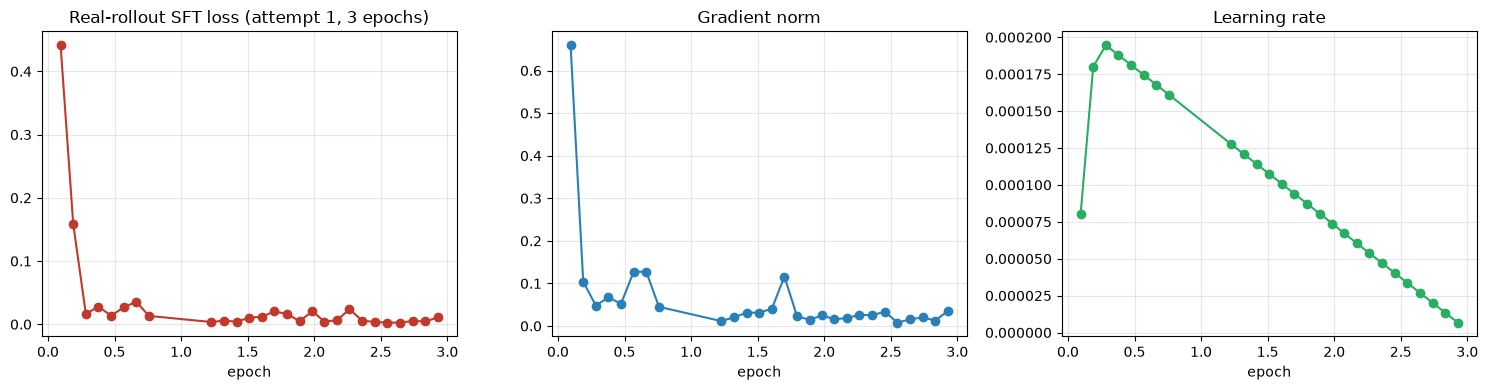

In [6]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_v1_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 1, 3 epochs)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 4: SFT on the 422 real multi-turn rollouts -- attempt 2 (current)

Same data and LoRA config as attempt 1, but **1 epoch only** (~53 steps total) and **checkpointing every 5 steps** (`save_strategy="steps"`, `save_steps=5`, `save_total_limit=12`) instead of once at the end. Since attempt 1's loss was already suspiciously low by step 15-20, the goal is to grab and evaluate one of the very early checkpoints (step 5 first) before memorization sets in, rather than training to full convergence and hoping it generalizes.

1 logged steps, latest loss = 0.4413 at epoch 0.09


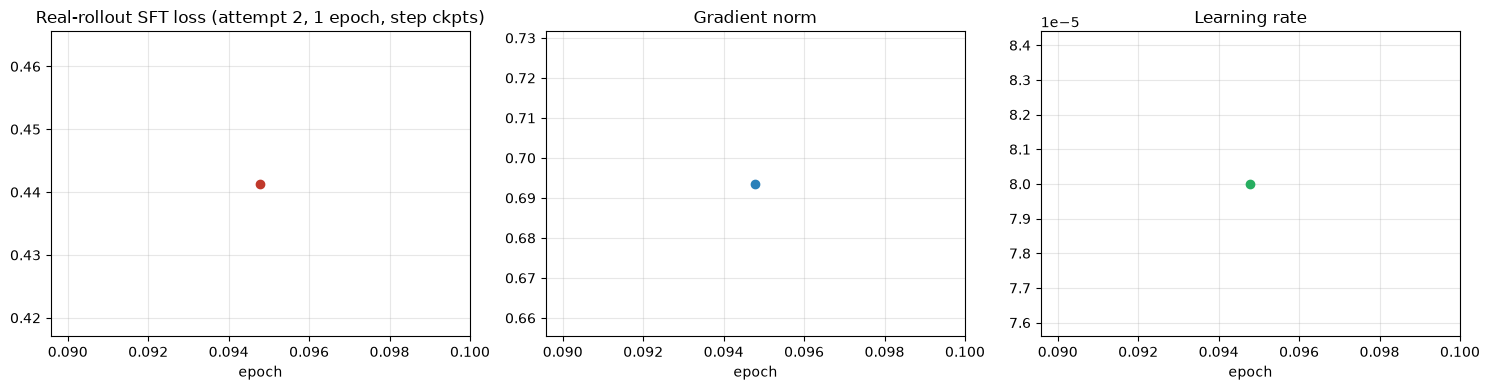

In [7]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_metrics.json"))
if not records:
    print("no training data yet -- job may still be downloading the base model")
else:
    epochs = [r["epoch"] for r in records]
    losses = [r["loss"] for r in records]
    grad_norms = [r["grad_norm"] for r in records]
    lrs = [r["learning_rate"] for r in records]
    print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 2, 1 epoch, step ckpts)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 5: τ-bench retail eval results, side by side

All runs are the full 115-task retail test split, GPT-4o as the user-simulator, same policy/tools/harness. **Baseline** is the untrained Qwen3-14B-AWQ. **Overfit** is the single-turn-SFT-trained model from Section 1 (catastrophic collapse). **Step 5** is the Section 4 run stopped at step 5 (~9% into epoch 1) -- essentially matches baseline, confirming that little training happened yet. Later checkpoints (step 10, 15...) get added here as they're evaluated, to find the point where real improvement (if any) shows up before memorization takes over.

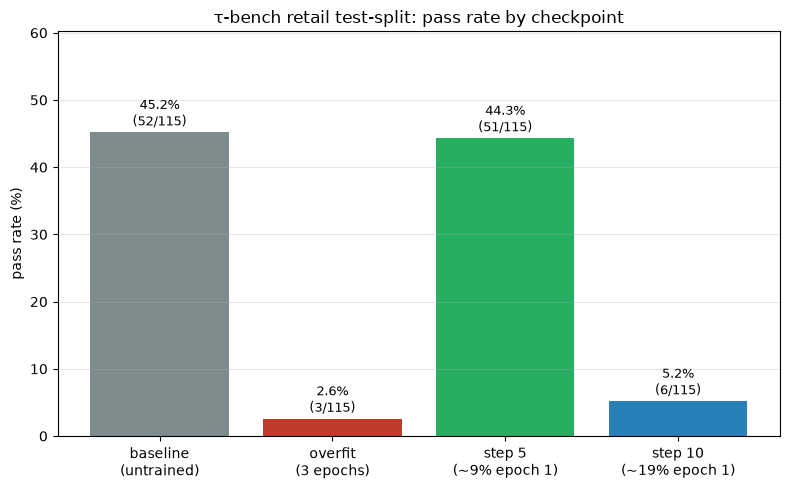

In [8]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/tau_eval_comparison.json"))
if not records:
    print("no eval comparison data yet")
else:
    labels = [r["label"] for r in records]
    pct = [100 * r["pass"] / r["total"] for r in records]
    colors = ["#7f8c8d", "#c0392b", "#27ae60", "#2980b9", "#8e44ad"][:len(records)]

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    bars = ax.bar(labels, pct, color=colors)
    for bar, r in zip(bars, records):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{100*r['pass']/r['total']:.1f}%\n({r['pass']}/{r['total']})", ha="center", fontsize=9)
    ax.set_ylabel("pass rate (%)")
    ax.set_title("τ-bench retail test-split: pass rate by checkpoint")
    ax.set_ylim(0, max(pct) + 15)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 6: pivot from SFT to RL (GRPO), same reward tau-bench itself uses

Root cause of the SFT collapse (see the `qwen3-14b-tau-train-overfitting` repo): a **positional shortcut**, not simple memorization -- 99.1% of training examples called the auth function, and 98% of those did it at the exact same message index (turn 4), teaching the model "fire auth around turn 4" instead of conditioning on whether real info was actually given. A data-level fix (the augmented dataset: zip/email-withheld negatives, policy-refusal examples, out-of-stock/nonexistent-lookup examples, all grounded in tau-bench's real orders/users/products DB) helps diversify the *targets*, but SFT still teaches "reproduce this one correct trajectory" -- so we're pivoting to RL, which only needs a pass/fail signal and lets the model find its own correct trajectories.

**Reward**: exactly tau-bench's own `calculate_reward()` (`tau_bench/envs/base.py`) -- no custom scoring. It replays the task's ground-truth mutating actions on a fresh copy of the retail DB, hashes the result, and compares to the hash produced by the agent's actual trajectory: reward = 1.0 iff they match (plus an optional output string-match check), else 0.0. Read-only tools (`calculate`, `find_user_id_by_email`, `find_user_id_by_name_zip`, `get_order_details`, `get_product_details`, `get_user_details`, `list_all_product_types`, `think`) never touch `self.data`, so they're naturally excluded from scoring either way -- only the 8 mutating tools (`cancel_pending_order`, `exchange_delivered_order_items`, `modify_pending_order_address`, `modify_pending_order_items`, `modify_pending_order_payment`, `modify_user_address`, `return_delivered_order_items`, `transfer_to_human_agents`) can move the hash off ground truth.

**Setup** (`grpo_train.py`, on a fresh RunPod A100-80GB pod since the previous one was terminated):
- Base model: `unsloth/Qwen3-14B-unsloth-bnb-4bit`, QLoRA r=16 (same target modules/config as the SFT runs), served from vLLM (`--quantization bitsandbytes --enable-lora`) **and** loaded separately via unsloth for the gradient updates -- one model, two roles, to avoid downloading/maintaining two quantization formats on the 30GB pod disk.
- Rollouts: tau-bench's own `ToolCallingAgent.solve()` reused unmodified, pointed at the vLLM server via litellm's `hosted_vllm` provider (isolated from `OPENAI_API_BASE`, which stays on `api.openai.com` for the GPT-4o user-simulator so both endpoints coexist). G=4 rollouts per task, temperature=1.0 for exploration.
- Advantage: standard GRPO group-relative normalization per task, `(r_i - mean(r_group)) / (std(r_group) + eps)`; tasks whose whole group scored identically (all-0 or all-1) are skipped -- no learning signal.
- Update: since vLLM (not the trainer) generated the tokens, logprobs of the exact assistant spans are recomputed via a teacher-forced forward pass on the trainer-side model (same `train_on_responses_only`-style masking as SFT -- only assistant tokens contribute). Loss per rollout = `-advantage * mean(logprob(assistant tokens))`. After each round the LoRA adapter is saved and hot-reloaded into vLLM via `/v1/load_lora_adapter`.
- First pass config: 4 tasks/round x 4 rollouts = 16 episodes/round, `lr=1e-5`, checkpointed every 5 rounds. Meant to be tuned once the mechanics are confirmed working.

11 rounds logged, latest avg_reward = 0.500 at round 10


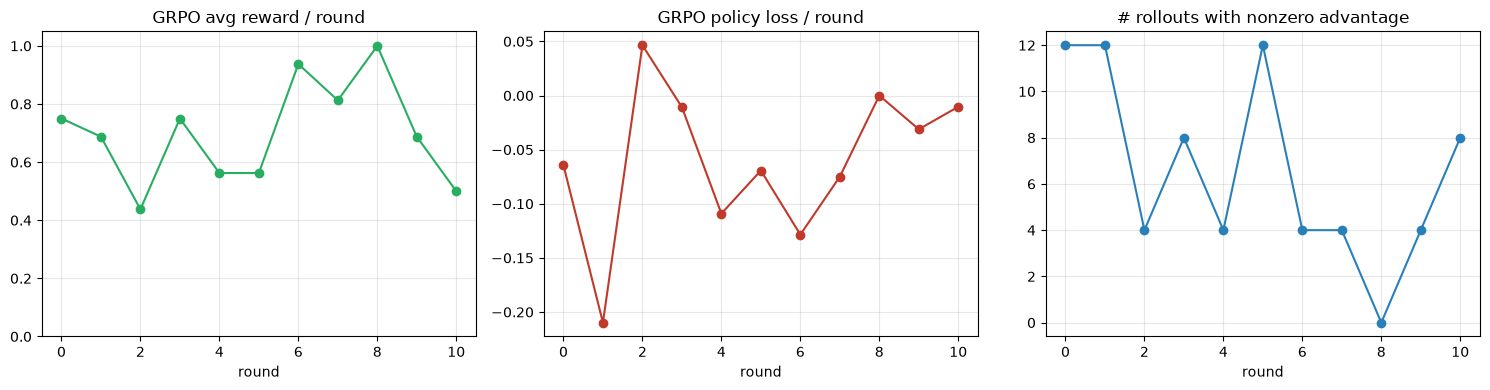

In [10]:
import json
import matplotlib.pyplot as plt

try:
    records = [json.loads(line) for line in open("full_run_results/grpo_train_log.jsonl")]
except FileNotFoundError:
    records = []
if not records:
    print("no GRPO training data yet -- job may still be starting up (vLLM model download, first rollouts)")
else:
    rounds = [r["round"] for r in records]
    avg_reward = [r["avg_reward"] for r in records]
    avg_loss = [r["avg_loss"] for r in records]
    n_updated = [r["n_updated"] for r in records]
    print(f"{len(records)} rounds logged, latest avg_reward = {avg_reward[-1]:.3f} at round {rounds[-1]}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(rounds, avg_reward, marker="o", color="#27ae60"); axes[0].set_title("GRPO avg reward / round"); axes[0].set_xlabel("round"); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
    axes[1].plot(rounds, avg_loss, marker="o", color="#c0392b"); axes[1].set_title("GRPO policy loss / round"); axes[1].set_xlabel("round"); axes[1].grid(alpha=0.3)
    axes[2].plot(rounds, n_updated, marker="o", color="#2980b9"); axes[2].set_title("# rollouts with nonzero advantage"); axes[2].set_xlabel("round"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Eval probe (the number that actually matters)

The chart above is the **training-time** reward -- noisy, small-batch (4 tasks/round), and mixes easy/hard tasks by luck of the draw, so it bounces around and can't tell us if the model is really improving. Every 5 rounds, a saved checkpoint is loaded into vLLM under its own adapter name (without touching the live training adapter) and run at temperature=0 against 20 fixed, real τ-bench **test**-split tasks (never seen during training, which only samples from the train split). That gives one clean, comparable number per checkpoint.

In [ ]:
import json
import matplotlib.pyplot as plt

try:
    records = json.load(open("full_run_results/grpo_eval_probe_log.json"))
except FileNotFoundError:
    records = []

if not records:
    print("no eval probe data yet")
else:
    original = sorted([r for r in records if r.get("run", "original") == "original"], key=lambda r: r["round"])
    rerun = sorted([r for r in records if r.get("run") == "rerun_with_transcripts"], key=lambda r: r["round"])
    best = max(records, key=lambda r: r["probe_avg_reward"])
    print(f"{len(records)} probe runs logged. best so far: round {best['round']} ({best.get('run','original')}) at {best['probe_avg_reward']:.2f}")

    fig, ax = plt.subplots(1, 1, figsize=(9, 5))

    # small horizontal offset so the two lines never sit exactly on top of
    # each other even where their values coincide (round 5, round 10)
    if original:
        x = [r["round"] - 0.15 for r in original]
        y = [r["probe_avg_reward"] for r in original]
        ax.plot(x, y, marker="o", markersize=9, color="#8e44ad", linewidth=2.5, label="original (drove the stop decision)", zorder=3)
        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(-4, 10), ha="right", fontsize=9, color="#8e44ad")
    if rerun:
        x = [r["round"] + 0.15 for r in rerun]
        y = [r["probe_avg_reward"] for r in rerun]
        ax.plot(x, y, marker="s", markersize=9, color="#d35400", linewidth=2.5, label="rerun (dialogues saved)", zorder=3)
        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(4, -14), ha="left", fontsize=9, color="#d35400")

    ax.set_title("Eval probe: pass rate on 20 fixed real test tasks, by checkpoint")
    ax.set_xlabel("training round")
    ax.set_ylabel("pass rate")
    ax.set_xticks(sorted(set(r["round"] for r in records)))
    ax.set_ylim(0, 0.75)
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 7: combo tasks -- the gap, and measuring what GRPO can actually learn from

**Why.** GRPO on the general train pool (Section 6) peaked after one round and then declined on the held-out probe. Clustering the real tau-bench tasks by scenario showed a likely reason: a *combo* task asks for 2+ distinct actions (return / exchange / cancel / modify / change payment) in one conversation, and combos are over-represented in the test split but under-represented in what we train on.

| source | combo share |
|---|---|
| test split | 64 / 115 (55.7%) |
| train split (500 tasks) | 153 / 500 (30.6%) |
| 422-example passing rollout set | 73 / 296 with a task_index (24.7%) |
| GRPO task slots, rounds 0-12 (rebuilt from the `random.seed(0)` task order) | 16 / 52 (30.8%) |

Rejection sampling keeps only passing rollouts, so harder multi-action tasks were filtered out of the SFT data: 80 of the 153 combo train tasks never produced a passing rollout.

**Why not just train on the 73 combos in the passing set.** They are tasks the base model already solved, so a GRPO group on them is mostly all-pass and gives a near-zero advantage. The other 80 may be the mirror case (all-fail). The old rejection-sampling run did not record per-task pass rates, so neither set is known to have the pass/fail mix GRPO needs.

**Diagnostic (measurement only, no weight updates).** Each of the 153 combo train tasks is rolled out 8 times at temperature 1.0 with the round-0 LoRA checkpoint (the best probe score), the real tau-bench retail env and GPT-4o as the simulated user. Tasks with an intermediate pass rate form the next GRPO pool. GRPO then runs on that pool with the same 20 fixed test-task probe checked every 5 rounds, stopping at the first sign of decline.

Setup notes: RTX A6000 46GB; vLLM 0.11.0 in its own venv (newer vLLM dropped bitsandbytes support); vLLM at 85% GPU memory with 48 concurrent rollouts for the measurement (the 40% setting from the training setup generated only ~213 tok/s).


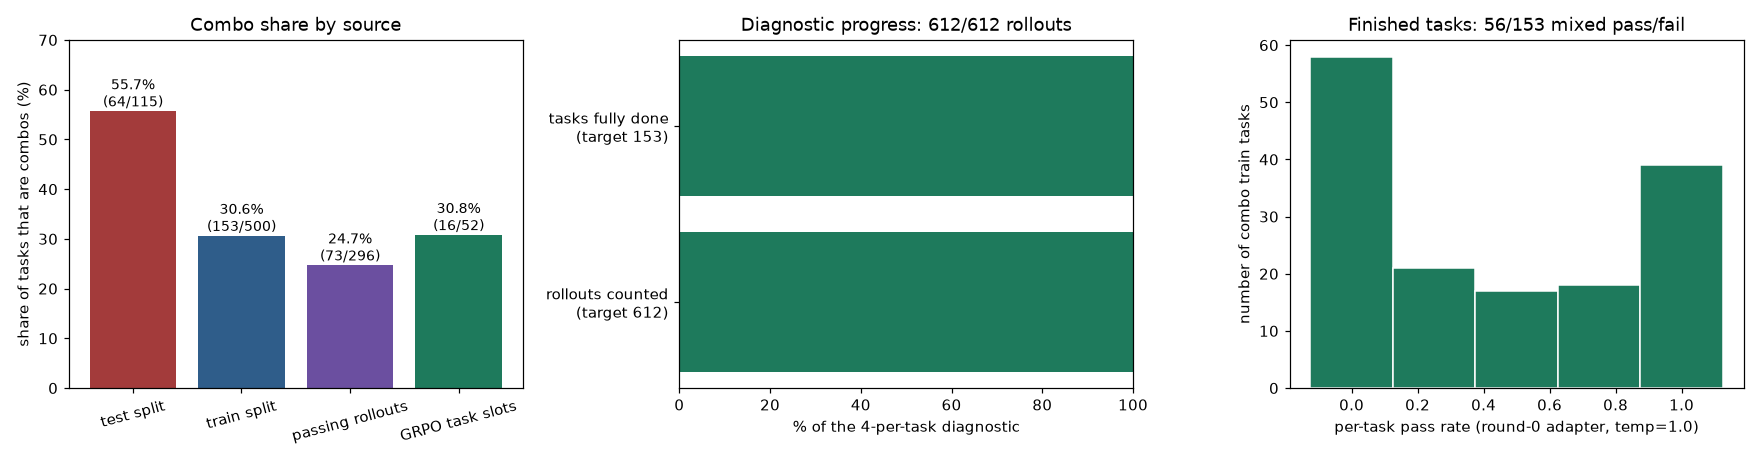

In [2]:
import json, collections
import matplotlib.pyplot as plt

sources = ["test split", "train split", "passing rollouts", "GRPO task slots"]
combo = [64, 153, 73, 16]
total = [115, 500, 296, 52]
shares = [100 * c / t for c, t in zip(combo, total)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].bar(sources, shares, color=["#A33B3B", "#2F5D8A", "#6B4FA0", "#1E7A5C"])
for i, (sh, c, t) in enumerate(zip(shares, combo, total)):
    axes[0].text(i, sh + 1, f"{sh:.1f}%\n({c}/{t})", ha="center", fontsize=9)
axes[0].set_ylim(0, 70)
axes[0].set_ylabel("share of tasks that are combos (%)")
axes[0].set_title("Combo share by source")
axes[0].tick_params(axis="x", labelrotation=15)

try:
    data = json.load(open("full_run_results/combo_passrate.json"))
    recs = data["rollouts"] if isinstance(data, dict) else data
    per_task = collections.defaultdict(list)
    for r in recs:
        per_task[r["task_index"]].append(r["reward"])
    counted = sum(min(len(v), 4) for v in per_task.values())
    axes[1].barh(["rollouts counted\n(target 612)", "tasks fully done\n(target 153)"],
                 [counted / 612 * 100, sum(len(v) >= 4 for v in per_task.values()) / 153 * 100],
                 color="#1E7A5C")
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("% of the 4-per-task diagnostic")
    axes[1].set_title(f"Diagnostic progress: {counted}/612 rollouts")
    rates = [sum(v) / len(v) for v in per_task.values() if len(v) >= 4]
    axes[2].hist(rates, bins=[i / 4 - 0.125 for i in range(6)], color="#1E7A5C", edgecolor="white")
    axes[2].set_xlabel("per-task pass rate (round-0 adapter, temp=1.0)")
    axes[2].set_ylabel("number of combo train tasks")
    mixed = sum(0 < r < 1 for r in rates)
    axes[2].set_title(f"Finished tasks: {mixed}/{len(rates)} mixed pass/fail")
except FileNotFoundError:
    for ax in axes[1:]:
        ax.text(0.5, 0.5, "pass-rate diagnostic not saved yet\n(full_run_results/combo_passrate.json)",
                ha="center", va="center")
        ax.set_axis_off()

plt.tight_layout()
plt.show()


### Combo pass-rate diagnostic: live status (auto-updated 2026-10-01 17:12)

| | |
|---|---|
| rollouts saved | 640 (1 errors) |
| counted toward 4/task target | 612 / 612 (100%) |
| tasks with all 4 rollouts | 153 / 153 |
| mean reward so far | 0.423 |
| of finished tasks: never pass / mixed / always pass | 58 / 56 / 39 |

<details><summary>All tasks measured so far (153), mixed first</summary>

| task | rewards | pass rate | category | target tool calls | instruction |
|---|---|---|---|---|---|
| 31 | 0111 | 0.75 | mixed | modify_pending_order_items, exchange_delivered_order_items | Your name is Olivia Lopez and your zip code is 76171. You are dependent, happy, confident, optimistic, cautiou... |
| 99 | 0111 | 0.75 | mixed | modify_pending_order_address, modify_pending_order_items, return_delivered_order_items | Your name is Noah Sanchez and your zip code is 20056. You are polite, curious. For #W8645374, change address t... |
| 111 | 1101 | 0.75 | mixed | exchange_delivered_order_items, exchange_delivered_order_items | Your name is Ethan Moore and your email is ethan.moore4935@example.com. You are patient, sad, flexible. For #W... |
| 127 | 0111 | 0.75 | mixed | return_delivered_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Lei Anderson and your zip code is 76192. You are creative, direct, pessimistic, patient, happy. R... |
| 147 | 1011 | 0.75 | mixed | modify_pending_order_items, return_delivered_order_items | Your name is Evelyn Hernandez and your zip code is 92139. You are rigid, insecure, pessimistic, outgoing, impa... |
| 157 | 1110 | 0.75 | mixed | exchange_delivered_order_items, modify_pending_order_items | Your name is Anya Lee and your email is anya.lee3013@example.com. You are busy, direct, happy, organized, outg... |
| 184 | 0111 | 0.75 | mixed | cancel_pending_order, modify_pending_order_items | Your name is Daiki Johnson and your email is daiki.johnson2279@example.com. You are optimistic, direct, rigid,... |
| 190 | 1110 | 0.75 | mixed | return_delivered_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Lei Anderson and your zip code is 76192. You are shy, impatient, curious, insecure. Return #W7242... |
| 198 | 1011 | 0.75 | mixed | modify_pending_order_items, modify_pending_order_items | Your name is Daiki Muller and your zip code is 94157. You are patient, sad. For #W6790887, modify Dumbbell Set... |
| 205 | 1101 | 0.75 | mixed | cancel_pending_order, return_delivered_order_items | Your name is Ethan Muller and your email is ethan.muller6617@example.com. You are relaxing, sad. Cancel order ... |
| 215 | 1011 | 0.75 | mixed | return_delivered_order_items, modify_pending_order_items | Your name is Yusuf Rossi and your zip code is 19122. You are sad, logical, polite, independent. Return #W23781... |
| 243 | 1101 | 0.75 | mixed | cancel_pending_order, modify_pending_order_address, modify_pending_order_items | Your name is Mia Jackson and your email is mia.jackson5798@example.com. You are busy, polite, independent, ins... |
| 317 | 0111 | 0.75 | mixed | cancel_pending_order, cancel_pending_order, cancel_pending_order | Your name is Ivan Santos and your email is ivan.santos3158@example.com. You are confident, sad. Cancel order #... |
| 319 | 1011 | 0.75 | mixed | modify_pending_order_items, modify_pending_order_payment, modify_pending_order_items | Your name is Omar Kim and your zip code is 32214. You are busy, happy, optimistic. For #W7111824, modify Espre... |
| 398 | 1011 | 0.75 | mixed | return_delivered_order_items, cancel_pending_order | Your name is Ava Moore and your zip code is 78234. You are dependent, flexible. Return #W8951014 via gift_card... |
| 424 | 1110 | 0.75 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Omar Santos and your email is omar.santos1752@example.com. You are flexible, patient. For #W91210... |
| 459 | 1011 | 0.75 | mixed | exchange_delivered_order_items, return_delivered_order_items | Your name is Chen Silva and your email is chen.silva2698@example.com. You are organized, busy. For #W2598834, ... |
| 470 | 0111 | 0.75 | mixed | exchange_delivered_order_items, cancel_pending_order | Your name is Yusuf Patel and your email is yusuf.patel5348@example.com. You are happy, cautious. For #W1052399... |
| 7 | 110010 | 0.50 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Lucas Martin and your email is lucas.martin5733@example.com. You are patient, cautious, organized... |
| 36 | 0110 | 0.50 | mixed | modify_pending_order_items, exchange_delivered_order_items | Your name is Mei Ahmed and your email is mei.ahmed4901@example.com. You are busy, impatient, organized, rigid,... |
| 83 | 0110 | 0.50 | mixed | exchange_delivered_order_items, exchange_delivered_order_items | Your name is Mei Ahmed and your email is mei.ahmed4901@example.com. You are flexible, messy, curious, direct, ... |
| 119 | 0011 | 0.50 | mixed | modify_pending_order_items, modify_pending_order_items | Your name is Olivia Ito and your zip code is 80218. You are polite, relaxing, curious, sad. For #W7941031, mod... |
| 134 | 1100 | 0.50 | mixed | exchange_delivered_order_items, cancel_pending_order | Your name is Noah Sanchez and your email is noah.sanchez7461@example.com. You are pessimistic, shy, happy, cre... |
| 148 | 1001 | 0.50 | mixed | modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items | Your name is Ivan Hernandez and your email is ivan.hernandez1120@example.com. You are flexible, patient, outgo... |
| 154 | 0101 | 0.50 | mixed | modify_pending_order_items, modify_pending_order_items | Your name is Emma Kovacs and your email is emma.kovacs5723@example.com. You are direct, happy, rigid. For #W71... |
| 191 | 0011 | 0.50 | mixed | modify_pending_order_items, cancel_pending_order | Your name is Sofia Thomas and your zip code is 75307. You are creative, independent, cautious, rigid, organize... |
| 221 | 1001 | 0.50 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Olivia Ito and your zip code is 80218. You are logical, curious. For #W7941031, change payment to... |
| 231 | 1010 | 0.50 | mixed | modify_pending_order_address, modify_pending_order_items, exchange_delivered_order_items | Your name is Aarav Davis and your zip code is 76150. You are busy, happy, direct, impatient, dependent. For #W... |
| 277 | 1010 | 0.50 | mixed | cancel_pending_order, modify_pending_order_payment, modify_pending_order_items | Your name is Fatima Li and your email is fatima.li1185@example.com. You are logical, sad, organized. Cancel or... |
| 309 | 1010 | 0.50 | mixed | exchange_delivered_order_items, cancel_pending_order | Your name is Chen Anderson and your email is chen.anderson4495@example.com. You are independent, cautious. For... |
| 374 | 0101 | 0.50 | mixed | modify_pending_order_items, exchange_delivered_order_items | Your name is Yusuf Gonzalez and your email is yusuf.gonzalez2399@example.com. You are polite, rigid, insecure.... |
| 433 | 0011 | 0.50 | mixed | modify_pending_order_address, modify_pending_order_items, exchange_delivered_order_items | Your name is Yusuf Hernandez and your zip code is 80265. You are confident, cautious. For #W2466703, change ad... |
| 434 | 0101 | 0.50 | mixed | modify_pending_order_items, cancel_pending_order, cancel_pending_order | Your name is Lei Ahmed and your email is lei.ahmed1696@example.com. You are dependent, messy, direct. For #W67... |
| 443 | 1100 | 0.50 | mixed | cancel_pending_order, exchange_delivered_order_items | Your name is Noah Kovacs and your email is noah.kovacs8240@example.com. You are patient, shy. Cancel order #W9... |
| 469 | 1100 | 0.50 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Daiki Li and your zip code is 75201. You are creative, impatient, curious. For #W6958840, change ... |
| 3 | 00101000 | 0.25 | mixed | exchange_delivered_order_items, cancel_pending_order | Your name is Sofia Kovacs and your zip code is 19049. You are patient, confident. For #W7736983, exchange Coff... |
| 27 | 0001 | 0.25 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Fatima Johnson and your email is fatima.johnson2300@example.com. You are creative, happy, curious... |
| 59 | 0001 | 0.25 | mixed | exchange_delivered_order_items, return_delivered_order_items | Your name is Anya Patel and your email is anya.patel9309@example.com. You are direct, sad, curious, logical, p... |
| 70 | 0001 | 0.25 | mixed | cancel_pending_order, modify_pending_order_payment, modify_pending_order_items | Your name is Omar Kim and your zip code is 32214. You are sad, relaxing, curious, creative, polite. Cancel ord... |
| 76 | 1000 | 0.25 | mixed | modify_pending_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Yusuf Taylor and your zip code is 95154. You are rigid, confident, independent, cautious, direct.... |
| 141 | 1000 | 0.25 | mixed | exchange_delivered_order_items, modify_pending_order_items, return_delivered_order_items | Your name is Olivia Ahmed and your zip code is 94152. You are confident, messy. For #W3972714, exchange Hiking... |
| 150 | 0001 | 0.25 | mixed | modify_pending_order_payment, modify_pending_order_items | Your name is Harper Santos and your zip code is 46237. You are direct, independent, happy, messy, busy. For #W... |
| 166 | 1000 | 0.25 | mixed | cancel_pending_order, modify_pending_order_payment, modify_pending_order_address, modify_pending_order_items | Your name is Anya Brown and your email is anya.brown8893@example.com. You are patient, insecure. Cancel order ... |
| 208 | 1000 | 0.25 | mixed | modify_pending_order_items, exchange_delivered_order_items | Your name is Ava Lopez and your zip code is 92168. You are polite, messy, busy, patient, flexible. For #W59110... |
| 222 | 0100 | 0.25 | mixed | modify_pending_order_items, return_delivered_order_items, cancel_pending_order | Your name is Anya Brown and your zip code is 10121. You are insecure, logical, sad, messy. For #W1430028, modi... |
| 233 | 0001 | 0.25 | mixed | modify_pending_order_address, modify_pending_order_items, modify_pending_order_items | Your name is Yusuf Hernandez and your zip code is 80265. You are confident, flexible. For #W6832752, change ad... |
| 276 | 0001 | 0.25 | mixed | modify_pending_order_items, exchange_delivered_order_items | Your name is Raj Moore and your zip code is 20566. You are curious, messy. For #W9929926, modify Bluetooth Spe... |
| 329 | 0010 | 0.25 | mixed | modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items, return_delivered_order_items | Your name is Anya Brown and your zip code is 10121. You are insecure, optimistic, direct. For #W1430028, chang... |
| 339 | 0010 | 0.25 | mixed | modify_pending_order_items, return_delivered_order_items | Your name is Ethan Kim and your zip code is 78286. You are messy, polite, optimistic, patient. For #W8296441, ... |
| 348 | 1000 | 0.25 | mixed | return_delivered_order_items, modify_pending_order_items | Your name is Evelyn Lopez and your zip code is 92195. You are creative, organized. Return #W1355800 via credit... |
| 360 | 0100 | 0.25 | mixed | modify_pending_order_items, return_delivered_order_items, cancel_pending_order | Your name is Amelia Silva and your zip code is 19117. You are shy, impatient, insecure, optimistic. For #W7342... |
| 365 | 0010 | 0.25 | mixed | cancel_pending_order, modify_pending_order_items | Your name is Ivan Khan and your zip code is 28243. You are confident, organized, creative, busy. Cancel order ... |
| 377 | 0001 | 0.25 | mixed | cancel_pending_order, modify_pending_order_items | Your name is Amelia Patel and your zip code is 85051. You are messy, impatient, relaxing. Cancel order #W90774... |
| 380 | 0001 | 0.25 | mixed | exchange_delivered_order_items, modify_pending_order_items, exchange_delivered_order_items | Your name is Lucas Brown and your email is lucas.brown9344@example.com. You are dependent, pessimistic, patien... |
| 445 | 1000 | 0.25 | mixed | cancel_pending_order, modify_pending_order_items, cancel_pending_order, cancel_pending_order | Your name is Ava Nguyen and your email is ava.nguyen2868@example.com. You are organized, curious, shy, busy, p... |
| 491 | 0001 | 0.25 | mixed | cancel_pending_order, modify_pending_order_items | Your name is Yusuf Ahmed and your email is yusuf.ahmed5476@example.com. You are organized, confident, busy, de... |
| 13 | 11111111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Emma Kovacs and your email is emma.kovacs5723@example.com. You are direct, sad. Cancel order #W71... |
| 29 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order, cancel_pending_order | Your name is Ava Nguyen and your zip code is 94128. You are logical, confident, busy. Cancel order #W1242543 b... |
| 43 | 1111 | 1.00 | always | cancel_pending_order, modify_pending_order_address, modify_pending_order_items | Your name is Lei Ahmed and your email is lei.ahmed1696@example.com. You are relaxing, independent. Cancel orde... |
| 44 | 1111 | 1.00 | always | modify_pending_order_items, cancel_pending_order | Your name is Sofia Rossi and your email is sofia.rossi2645@example.com. You are dependent, rigid, creative, co... |
| 46 | 1111 | 1.00 | always | return_delivered_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Lei Anderson and your zip code is 76192. You are impatient, confident, dependent. Return #W724281... |
| 47 | 1111 | 1.00 | always | cancel_pending_order, return_delivered_order_items | Your name is Mei Kovacs and your email is mei.kovacs8232@example.com. You are dependent, busy, outgoing, impat... |
| 49 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Emma Kovacs and your email is emma.kovacs5723@example.com. You are shy, patient, rigid, independe... |
| 53 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order, modify_pending_order_items | Your name is Anya Brown and your email is anya.brown8893@example.com. You are insecure, shy. Cancel order #W14... |
| 57 | 1111 | 1.00 | always | cancel_pending_order, exchange_delivered_order_items | Your name is Amelia Silva and your zip code is 19117. You are cautious, independent, patient. Cancel order #W4... |
| 78 | 1111 | 1.00 | always | cancel_pending_order, return_delivered_order_items | Your name is Isabella Santos and your zip code is 10020. You are flexible, creative, pessimistic. Cancel order... |
| 84 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items | Your name is Chen Silva and your email is chen.silva2698@example.com. You are optimistic, rigid, happy, busy, ... |
| 87 | 1111 | 1.00 | always | cancel_pending_order, exchange_delivered_order_items | Your name is Mohamed Lee and your email is mohamed.lee1888@example.com. You are sad, optimistic. Cancel order ... |
| 100 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Yusuf Garcia and your zip code is 46202. You are curious, outgoing, busy. Cancel order #W7639559 ... |
| 128 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items | Your name is Olivia Smith and your zip code is 80216. You are flexible, relaxing, insecure, patient, direct. R... |
| 156 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Evelyn Ahmed and your email is evelyn.ahmed2006@example.com. You are patient, rigid, busy. Cancel... |
| 168 | 1111 | 1.00 | always | cancel_pending_order, return_delivered_order_items | Your name is Lei Anderson and your zip code is 76192. You are polite, patient. Cancel order #W6002467 because ... |
| 172 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Raj Lopez and your email is raj.lopez2997@example.com. You are rigid, optimistic, confident. Canc... |
| 200 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Emma Santos and your zip code is 78228. You are dependent, impatient, relaxing. Cancel order #W16... |
| 212 | 1111 | 1.00 | always | return_delivered_order_items, cancel_pending_order | Your name is Lucas Muller and your zip code is 78763. You are shy, messy, patient. Return #W1523776 via gift_c... |
| 217 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Aarav Gonzalez and your email is aarav.gonzalez9269@example.com. You are relaxing, creative, happ... |
| 234 | 1111 | 1.00 | always | exchange_delivered_order_items, cancel_pending_order | Your name is Evelyn Hernandez and your zip code is 92139. You are logical, cautious, confident. For #W9628587,... |
| 241 | 1111 | 1.00 | always | return_delivered_order_items, cancel_pending_order | Your name is Anya Lee and your zip code is 78227. You are outgoing, polite, patient, logical, independent. Ret... |
| 255 | 1111 | 1.00 | always | exchange_delivered_order_items, return_delivered_order_items, return_delivered_order_items | Your name is Chen Silva and your zip code is 46281. You are messy, optimistic, insecure, cautious. For #W95716... |
| 260 | 1111 | 1.00 | always | return_delivered_order_items, cancel_pending_order | Your name is Chen Anderson and your email is chen.anderson4495@example.com. You are dependent, insecure, organ... |
| 261 | 1111 | 1.00 | always | modify_pending_order_items, cancel_pending_order | Your name is Ethan Lopez and your email is ethan.lopez8943@example.com. You are cautious, relaxing. For #W8073... |
| 265 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order, modify_pending_order_items | Your name is Lei Ahmed and your email is lei.ahmed1696@example.com. You are pessimistic, organized. Cancel ord... |
| 270 | 1111 | 1.00 | always | modify_pending_order_items, return_delivered_order_items | Your name is Aarav Gonzalez and your email is aarav.gonzalez9269@example.com. You are direct, pessimistic, shy... |
| 275 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items, modify_pending_order_items | Your name is Liam Thomas and your zip code is 85049. You are organized, polite, flexible, busy, cautious. Retu... |
| 280 | 1111 | 1.00 | always | cancel_pending_order, exchange_delivered_order_items | Your name is Noah Kovacs and your zip code is 20566. You are patient, dependent, cautious, creative, relaxing.... |
| 297 | 1111 | 1.00 | always | modify_pending_order_payment, modify_pending_order_items | Your name is Sofia Li and your zip code is 75390. You are flexible, organized, relaxing. For #W6599568, change... |
| 299 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Raj Lopez and your email is raj.lopez2997@example.com. You are relaxing, messy, happy. Cancel ord... |
| 327 | 1111 | 1.00 | always | return_delivered_order_items, cancel_pending_order | Your name is Ethan Kim and your email is ethan.kim3231@example.com. You are rigid, cautious, polite, confident... |
| 345 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items, cancel_pending_order | Your name is Sofia Li and your zip code is 78260. You are independent, insecure, pessimistic, sad. Return #W39... |
| 355 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items | Your name is Ethan Kim and your email is ethan.kim3231@example.com. You are curious, impatient. Return #W17633... |
| 367 | 1111 | 1.00 | always | return_delivered_order_items, cancel_pending_order | Your name is Sophia Hernandez and your zip code is 76197. You are shy, creative, independent, pessimistic. Ret... |
| 369 | 1111 | 1.00 | always | modify_pending_order_payment, modify_pending_order_address, modify_pending_order_items | Your name is Aarav Gonzalez and your zip code is 78268. You are direct, organized, patient. For #W6979932, cha... |
| 422 | 1111 | 1.00 | always | cancel_pending_order, exchange_delivered_order_items | Your name is Yara Silva and your zip code is 77159. You are dependent, pessimistic. Cancel order #W3730488 bec... |
| 476 | 1111 | 1.00 | always | cancel_pending_order, cancel_pending_order | Your name is Aarav Davis and your email is aarav.davis1165@example.com. You are optimistic, flexible, relaxing... |
| 477 | 1111 | 1.00 | always | return_delivered_order_items, return_delivered_order_items | Your name is Chen Anderson and your email is chen.anderson4495@example.com. You are insecure, patient. Return ... |
| 5 | 0000000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Harper Thomas and your email is harper.thomas1454@example.com. You are logical, dependent, impati... |
| 8 | 00000000 | 0.00 | never | modify_pending_order_items, return_delivered_order_items | Your name is Lucas Muller and your email is lucas.muller7899@example.com. You are patient, cautious. For #W320... |
| 12 | 00000000 | 0.00 | never | cancel_pending_order, cancel_pending_order, modify_pending_order_address, modify_pending_order_items | Your name is Harper Johansson and your zip code is 80281. You are happy, direct, confident, optimistic. Cancel... |
| 20 | 0000000 | 0.00 | never | modify_pending_order_items, modify_pending_order_items, exchange_delivered_order_items | Your name is Ethan Lopez and your email is ethan.lopez8943@example.com. You are pessimistic, patient, confiden... |
| 24 | 00000000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Juan Rossi and your zip code is 77209. You are independent, shy, curious, relaxing. For #W7602708... |
| 35 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, return_delivered_order_items, exchange_delivered_order_items | Your name is Isabella Johansson and your email is isabella.johansson9391@example.com. You are polite, pessimis... |
| 55 | 0000 | 0.00 | never | cancel_pending_order, modify_pending_order_items | Your name is Raj Lopez and your email is raj.lopez2997@example.com. You are polite, logical, dependent. Cancel... |
| 68 | 0000 | 0.00 | never | cancel_pending_order, cancel_pending_order, modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items | Your name is Mia Jackson and your email is mia.jackson5798@example.com. You are patient, insecure, shy, curiou... |
| 69 | 0000 | 0.00 | never | cancel_pending_order, exchange_delivered_order_items, exchange_delivered_order_items | Your name is Lucas Brown and your email is lucas.brown9344@example.com. You are creative, cautious, happy. Can... |
| 80 | 0000 | 0.00 | never | modify_pending_order_items, modify_pending_order_payment, modify_pending_order_items | Your name is Olivia Ito and your email is olivia.ito5204@example.com. You are dependent, organized, insecure. ... |
| 92 | 0000 | 0.00 | never | exchange_delivered_order_items, modify_pending_order_items | Your name is Ethan Muller and your email is ethan.muller6617@example.com. You are optimistic, polite, rigid. F... |
| 102 | 0000 | 0.00 | never | return_delivered_order_items, exchange_delivered_order_items | Your name is Noah Sanchez and your email is noah.sanchez7461@example.com. You are logical, polite, impatient, ... |
| 117 | 0000 | 0.00 | never | exchange_delivered_order_items, return_delivered_order_items | Your name is Yara Ito and your email is yara.ito7353@example.com. You are organized, happy, dependent, polite,... |
| 130 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items, cancel_pending_order | Your name is Evelyn Ahmed and your email is evelyn.ahmed2006@example.com. You are creative, sad, patient, poli... |
| 139 | 0000 | 0.00 | never | modify_pending_order_items, return_delivered_order_items, modify_pending_order_address, modify_pending_order_items, cancel_pending_order | Your name is Evelyn Kovacs and your email is evelyn.kovacs5369@example.com. You are rigid, sad, shy, independe... |
| 146 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items, modify_pending_order_payment, modify_pending_order_items | Your name is Yusuf Gonzalez and your email is yusuf.gonzalez2399@example.com. You are outgoing, sad, flexible,... |
| 149 | 0000 | 0.00 | never | modify_pending_order_items, cancel_pending_order | Your name is Evelyn Lopez and your email is evelyn.lopez6910@example.com. You are organized, sad, confident. F... |
| 176 | 0000 | 0.00 | never | exchange_delivered_order_items, modify_pending_order_items, cancel_pending_order, modify_pending_order_items | Your name is Ethan Lopez and your zip code is 43275. You are cautious, messy, creative, direct. For #W8632528,... |
| 192 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items, exchange_delivered_order_items | Your name is Harper Brown and your zip code is 76112. You are organized, patient, sad, dependent, cautious. Fo... |
| 193 | 0000 | 0.00 | never | exchange_delivered_order_items, exchange_delivered_order_items | Your name is Daiki Patel and your zip code is 94111. You are organized, flexible, optimistic, happy. For #W896... |
| 197 | 0000 | 0.00 | never | modify_pending_order_items, return_delivered_order_items, modify_pending_order_address, modify_pending_order_items, cancel_pending_order | Your name is Fatima Muller and your zip code is 60644. You are confident, optimistic, polite, messy, independe... |
| 201 | 0000 | 0.00 | never | cancel_pending_order, exchange_delivered_order_items | Your name is Noah Sanchez and your email is noah.sanchez7461@example.com. You are flexible, busy. Cancel order... |
| 203 | 0000 | 0.00 | never | return_delivered_order_items, return_delivered_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Lucas Brown and your zip code is 60612. You are rigid, polite, cautious, confident. Return #W8660... |
| 206 | 0000 | 0.00 | never | exchange_delivered_order_items, return_delivered_order_items | Your name is Mei Kovacs and your email is mei.kovacs8232@example.com. You are rigid, curious, insecure, relaxi... |
| 238 | 0000 | 0.00 | never | cancel_pending_order, modify_pending_order_items | Your name is Yara Muller and your email is yara.muller9246@example.com. You are rigid, shy, confident. Cancel ... |
| 245 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items, return_delivered_order_items, modify_pending_order_items, cancel_pending_order | Your name is Ava Nguyen and your zip code is 94128. You are relaxing, cautious, organized, logical. For #W6272... |
| 248 | 0000 | 0.00 | never | cancel_pending_order, modify_pending_order_address, modify_pending_order_items, cancel_pending_order, modify_pending_order_items | Your name is Harper Johansson and your zip code is 80281. You are sad, pessimistic, busy, creative, curious. C... |
| 252 | 0000 | 0.00 | never | exchange_delivered_order_items, cancel_pending_order, cancel_pending_order | Your name is Emma Santos and your zip code is 78228. You are creative, sad, pessimistic, impatient, busy. For ... |
| 253 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Fatima Anderson and your zip code is 78786. You are pessimistic, rigid, sad, shy, messy. For #W63... |
| 267 | 0000 | 0.00 | never | return_delivered_order_items, modify_pending_order_items | Your name is Isabella Santos and your email is isabella.santos9317@example.com. You are dependent, sad. Return... |
| 290 | 0000 | 0.00 | never | modify_pending_order_items, return_delivered_order_items, cancel_pending_order | Your name is Yara Silva and your zip code is 77159. You are dependent, relaxing, creative. For #W9810810, modi... |
| 298 | 0000 | 0.00 | never | cancel_pending_order, modify_pending_order_items, exchange_delivered_order_items | Your name is Olivia Ito and your zip code is 80218. You are independent, rigid. Cancel order #W3657213 because... |
| 305 | 0000 | 0.00 | never | cancel_pending_order, modify_pending_order_items, return_delivered_order_items, modify_pending_order_items, modify_pending_order_items | Your name is Ava Nguyen and your zip code is 94128. You are outgoing, happy, direct. Cancel order #W6272294 be... |
| 314 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Aarav Davis and your email is aarav.davis1165@example.com. You are organized, patient, independen... |
| 322 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Olivia Lopez and your email is olivia.lopez8783@example.com. You are cautious, organized, creativ... |
| 328 | 0000 | 0.00 | never | exchange_delivered_order_items, exchange_delivered_order_items | Your name is Sofia Hernandez and your email is sofia.hernandez3039@example.com. You are optimistic, logical, f... |
| 331 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items, modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items, exchange_delivered_order_items | Your name is Ivan Khan and your email is ivan.khan6479@example.com. You are organized, confident, logical, sad... |
| 334 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, return_delivered_order_items, exchange_delivered_order_items | Your name is Olivia Ahmed and your zip code is 94152. You are shy, patient. For #W2609687, change address to {... |
| 351 | 0000 | 0.00 | never | cancel_pending_order, exchange_delivered_order_items, modify_pending_order_payment, modify_pending_order_items, return_delivered_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Emma Santos and your email is emma.santos7683@example.com. You are impatient, messy, independent,... |
| 361 | 0000 | 0.00 | never | exchange_delivered_order_items, modify_pending_order_items | Your name is Sofia Moore and your email is sofia.moore4274@example.com. You are cautious, direct, patient, mes... |
| 368 | 0000 | 0.00 | never | cancel_pending_order, exchange_delivered_order_items, modify_pending_order_items | Your name is Fatima Muller and your zip code is 60644. You are logical, messy, insecure, polite, curious. Canc... |
| 376 | 0000 | 0.00 | never | exchange_delivered_order_items, modify_pending_order_items | Your name is Sophia Hernandez and your email is sophia.hernandez3499@example.com. You are optimistic, sad, fle... |
| 393 | 0000 | 0.00 | never | return_delivered_order_items, modify_pending_order_items, exchange_delivered_order_items | Your name is Liam Thomas and your zip code is 85049. You are outgoing, impatient, logical. Return #W8488728 vi... |
| 402 | 0000 | 0.00 | never | exchange_delivered_order_items, return_delivered_order_items | Your name is Ethan Muller and your zip code is 98128. You are creative, confident, happy, cautious. For #W4398... |
| 410 | 0000 | 0.00 | never | return_delivered_order_items, exchange_delivered_order_items | Your name is Sophia Hernandez and your zip code is 76197. You are busy, direct. Return #W1748126 via gift_card... |
| 415 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Emma Kovacs and your zip code is 95111. You are shy, creative. For #W6554908, change address to {... |
| 416 | 0000 | 0.00 | never | modify_pending_order_items, modify_pending_order_items, exchange_delivered_order_items | Your name is Yusuf Garcia and your email is yusuf.garcia2909@example.com. You are dependent, rigid. For #W3260... |
| 427 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items, modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items | Your name is Ava Lopez and your email is ava.lopez3569@example.com. You are optimistic, direct. For #W5911003,... |
| 429 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Raj Lopez and your zip code is 76195. You are flexible, shy. For #W5107138, change payment to pay... |
| 431 | 0000 | 0.00 | never | cancel_pending_order, return_delivered_order_items, exchange_delivered_order_items, modify_pending_order_address, modify_pending_order_payment, modify_pending_order_items | Your name is Yusuf Garcia and your email is yusuf.garcia2909@example.com. You are independent, organized, outg... |
| 441 | 0000 | 0.00 | never | modify_pending_order_items, return_delivered_order_items | Your name is Ethan Kim and your email is ethan.kim3231@example.com. You are pessimistic, independent, happy. F... |
| 451 | 0000 | 0.00 | never | exchange_delivered_order_items, modify_pending_order_address, modify_pending_order_items, exchange_delivered_order_items | Your name is Sofia Li and your zip code is 78260. You are insecure, independent, organized, optimistic. For #W... |
| 462 | 0000 | 0.00 | never | cancel_pending_order, cancel_pending_order, modify_pending_order_items | Your name is Olivia Jackson and your zip code is 95119. You are outgoing, polite, busy, organized. Cancel orde... |
| 463 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Anya Patel and your email is anya.patel9309@example.com. You are rigid, organized. For #W4604258,... |
| 464 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, modify_pending_order_address, modify_pending_order_items | Your name is Evelyn Kovacs and your zip code is 32117. You are optimistic, cautious, dependent, direct. For #W... |
| 467 | 0000 | 0.00 | never | modify_pending_order_payment, modify_pending_order_items | Your name is Evelyn Ahmed and your zip code is 80256. You are messy, creative, direct, outgoing, sad. For #W37... |
| 474 | 0000 | 0.00 | never | modify_pending_order_address, modify_pending_order_items, exchange_delivered_order_items | Your name is Lei Li and your email is lei.li8350@example.com. You are independent, messy. For #W5166363, chang... |
| 497 | 0000 | 0.00 | never | exchange_delivered_order_items, cancel_pending_order, cancel_pending_order | Your name is Emma Santos and your zip code is 78228. You are creative, sad, curious. For #W1539823, exchange I... |

</details>

Generated by `update_notebook.py`; the chart above reads `full_run_results/combo_passrate.json` (per-task summaries + raw rollouts).


## Section 8: GRPO on the combo pool (live)

Resumes from the round-0 LoRA checkpoint and trains GRPO only on the 56 *mixed pass/fail* combo
train tasks found in Section 7 (4 tasks per round, 4 rollouts each, lr 1e-5). The signal is the
held-out probe (the same 20 real test tasks at temperature 0), not the training reward: it is scored
for the original round-0 adapter first (the baseline, labelled `-1`) and then for every saved
checkpoint. The pod stops training itself if a probe drops more than 0.10 below the best so far.

Notes from setting this up: with two LoRA adapters live (the training policy and the probe), vLLM
needed `--max-loras 3`; with the default of 1 the adapters took turns and rollouts timed out. This
section's data file is rewritten every 30 seconds by `live_grpo_section.py`; the chart and status cells below
are code cells, so re-run them to redraw (set `LIVE = True` in the status cell to have it redraw itself).


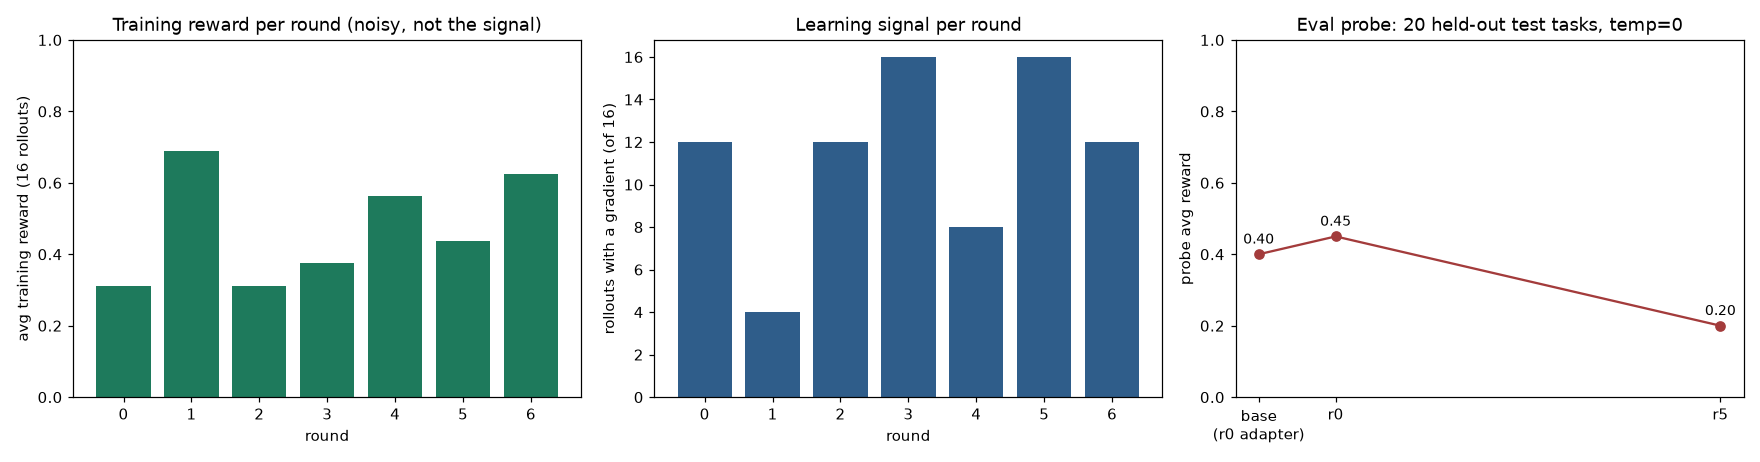

In [ ]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/combo_grpo_run.json"))
rounds = [r for r in run["rounds"] if "avg_reward" in r]
probes = run["probes"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
if rounds:
    xs = [r["round"] for r in rounds]
    axes[0].bar(xs, [r["avg_reward"] for r in rounds], color="#1E7A5C")
    axes[0].set_ylim(0, 1)
axes[0].set_xlabel("round")
axes[0].set_ylabel("avg training reward (16 rollouts)")
axes[0].set_title("Training reward per round (noisy, not the signal)")

if rounds:
    axes[1].bar([r["round"] for r in rounds], [r.get("n_updated", 0) for r in rounds], color="#2F5D8A")
axes[1].set_xlabel("round")
axes[1].set_ylabel("rollouts with a gradient (of 16)")
axes[1].set_title("Learning signal per round")

if probes:
    px = [p["round"] for p in probes]
    py = [p["probe_avg_reward"] for p in probes]
    axes[2].plot(px, py, marker="o", color="#A33B3B")
    for x, y in zip(px, py):
        axes[2].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
    axes[2].set_ylim(0, 1)
    axes[2].set_xticks(px)
    axes[2].set_xticklabels(["base\n(r0 adapter)" if x == -1 else f"r{x}" for x in px])
else:
    axes[2].text(0.5, 0.5, "no probe scores yet", ha="center", va="center")
    axes[2].set_axis_off()
axes[2].set_title("Eval probe: 20 held-out test tasks, temp=0")
axes[2].set_ylabel("probe avg reward")

plt.tight_layout()
plt.show()


In [ ]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/combo_grpo_run.json"
LIVE = False  # True: keep re-reading and redrawing this cell every 30 s until the trainer stops (interrupt to stop)


def _mark(v):
    return "".join("1" if x else "0" for x in v)


def render_html(run):
    rounds = run["rounds"]
    done = [r for r in rounds if "avg_reward" in r]
    fin = [datetime.datetime.fromisoformat(r["finished_at"]) for r in done if r.get("finished_at")]
    gaps = [(b - a).total_seconds() for a, b in zip(fin, fin[1:])]
    state = ("running" if run["running"] else
             ("stopped on decline: " + run["stopped_on_decline"]) if run.get("stopped_on_decline") else "not running")
    lu, uu = run.get("last_update", ""), run.get("last_update_utc", "")
    best = max(run["probes"], key=lambda p: p["probe_avg_reward"]) if run["probes"] else None
    t = "border-collapse:collapse;margin:6px 0 14px"
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='{t}'><tr>{h}</tr>{b}</table>"
    out = [f"<h4>Combo GRPO run: live status (data written {html.escape(lu)} = {html.escape(uu)})</h4>"]
    out.append(table(["", ""], [
        ["trainer", state],
        ["rounds finished", f"{len(done)} / {run['max_rounds']} max"],
        ["minutes per round (observed)", f"{sum(gaps) / len(gaps) / 60:.1f}" if gaps else "-"],
        ["rollout errors", sum(r["errors"] for r in rounds)],
        ["best probe so far", f"{best['probe_avg_reward']:.2f} (round {best['round']})" if best else "-"],
    ]))
    out.append("<b>Probe scores</b>" + table(["checkpoint", "probe avg reward"], [
        ["baseline (original round-0 adapter)" if p["round"] == -1 else f"round {p['round']}", f"{p['probe_avg_reward']:.2f}"]
        for p in run["probes"]] or [["none yet", ""]]))
    out.append("<b>Rounds</b>" + table(["round", "tasks (reward per rollout)", "avg reward", "gradient rollouts", "errors"], [
        [r["round"], html.escape("; ".join(f"{k}: {_mark(v)}" for k, v in r["tasks"].items()) or "running..."),
         f"{r['avg_reward']:.2f}" if "avg_reward" in r else "-",
         f"{r['n_updated']}/{r['n_rollouts']}" if "n_updated" in r else "-", r["errors"]] for r in rounds]))
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if not run["running"]:
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


<combo GRPO live status>

### Section 8 result: stopped on decline at round 7

| checkpoint | probe (20 held-out test tasks, temp 0) |
|---|---|
| baseline: original round-0 adapter | 0.40 |
| combo-GRPO round 0 (1 update) | 0.45 |
| combo-GRPO round 5 | **0.20** |

The pod's rule (probe more than 0.10 below the best so far) stopped training during round 7. Training reward
over rounds 0-6 stayed between 0.31 and 0.69 with no trend (it mostly tracks which tasks were drawn), so it did
not predict the drop; only the held-out probe did. This matches the first GRPO run in Section 6 (0.55 -> 0.35 -> 0.30):
a short run on a small task pool improves or holds briefly, then the held-out score falls.

Caveats: the probe has only 20 tasks, so it is noisy (about +/-0.1 per run), and 0.20 vs 0.40-0.45 is a 4-5 task gap,
suggestive rather than conclusive on its own; two runs falling the same way is the stronger evidence. Checkpoints were
saved only at rounds 0 and 5, so the decline cannot be located between them. Local copies: `saves/combo-round-0`, `saves/combo-round-5`.


## Section 9: gentle GRPO on the combo pool (live)

Second attempt after Section 8 stopped on a decline (probe 0.45 -> 0.20 by round 5). Same start (the round-0 LoRA
adapter) and same pool (the 56 mixed pass/fail combo train tasks), but the learning rate is 10x lower (1e-6 instead of
1e-5). Checkpoints are saved and scored at rounds 1, 3, 5 and every 5 after, on the same 20 held-out test tasks at
temperature 0 (baseline 0.40 reused from Section 8). The pod stops training if a probe falls more than 0.15 below the
best so far (a wider margin than Section 8, because the 20-task probe is noisy by about 0.1). The 15-round cap applies.

The data file for this section is rewritten every 30 seconds by `live_gentle_section.py`; re-run the chart and status cells
below to redraw them (set `LIVE = True` in the status cell to have it redraw itself).


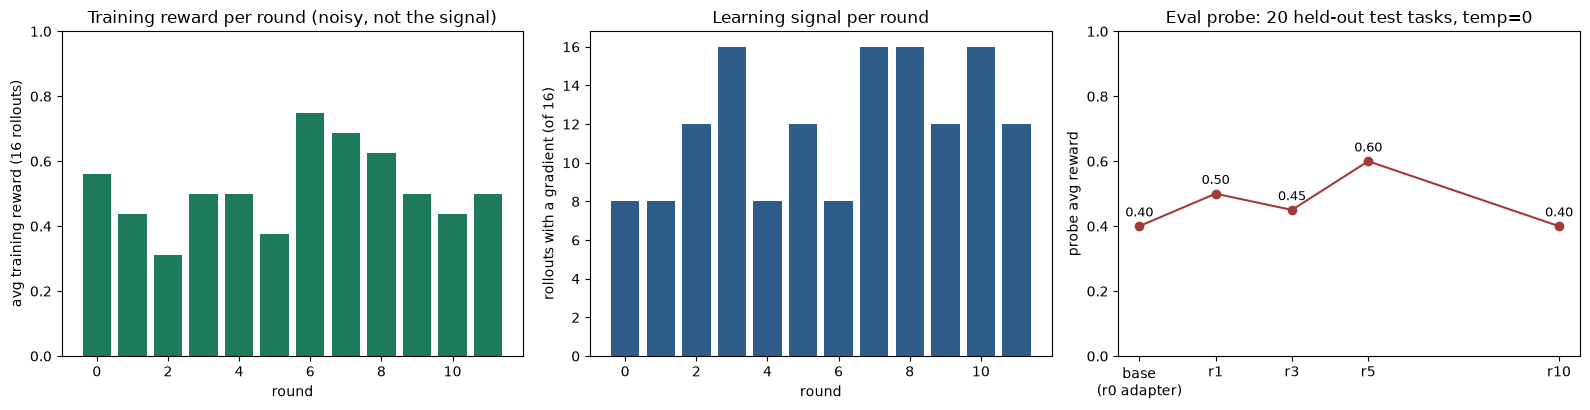

In [47]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/gentle_grpo_run.json"))
rounds = [r for r in run["rounds"] if "avg_reward" in r]
probes = run["probes"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
if rounds:
    xs = [r["round"] for r in rounds]
    axes[0].bar(xs, [r["avg_reward"] for r in rounds], color="#1E7A5C")
    axes[0].set_ylim(0, 1)
axes[0].set_xlabel("round")
axes[0].set_ylabel("avg training reward (16 rollouts)")
axes[0].set_title("Training reward per round (noisy, not the signal)")

if rounds:
    axes[1].bar([r["round"] for r in rounds], [r.get("n_updated", 0) for r in rounds], color="#2F5D8A")
axes[1].set_xlabel("round")
axes[1].set_ylabel("rollouts with a gradient (of 16)")
axes[1].set_title("Learning signal per round")

if probes:
    px = [p["round"] for p in probes]
    py = [p["probe_avg_reward"] for p in probes]
    axes[2].plot(px, py, marker="o", color="#A33B3B")
    for x, y in zip(px, py):
        axes[2].annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
    axes[2].set_ylim(0, 1)
    axes[2].set_xticks(px)
    axes[2].set_xticklabels(["base\n(r0 adapter)" if x == -1 else f"r{x}" for x in px])
else:
    axes[2].text(0.5, 0.5, "no probe scores yet", ha="center", va="center")
    axes[2].set_axis_off()
axes[2].set_title("Eval probe: 20 held-out test tasks, temp=0")
axes[2].set_ylabel("probe avg reward")

plt.tight_layout()
plt.show()


In [48]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/gentle_grpo_run.json"
LIVE = False  # True: keep re-reading and redrawing this cell every 30 s until the trainer stops (interrupt to stop)


def _mark(v):
    return "".join("1" if x else "0" for x in v)


def render_html(run):
    rounds = run["rounds"]
    done = [r for r in rounds if "avg_reward" in r]
    fin = [datetime.datetime.fromisoformat(r["finished_at"]) for r in done if r.get("finished_at")]
    gaps = [(b - a).total_seconds() for a, b in zip(fin, fin[1:])]
    state = ("running" if run["running"] else
             ("stopped on decline: " + run["stopped_on_decline"]) if run.get("stopped_on_decline") else "not running")
    lu, uu = run.get("last_update", ""), run.get("last_update_utc", "")
    best = max(run["probes"], key=lambda p: p["probe_avg_reward"]) if run["probes"] else None
    t = "border-collapse:collapse;margin:6px 0 14px"
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='{t}'><tr>{h}</tr>{b}</table>"
    out = [f"<h4>Gentle combo GRPO run: live status (data written {html.escape(lu)} = {html.escape(uu)})</h4>"]
    out.append(table(["", ""], [
        ["trainer", state],
        ["rounds finished", f"{len(done)} / {run['max_rounds']} max"],
        ["minutes per round (observed)", f"{sum(gaps) / len(gaps) / 60:.1f}" if gaps else "-"],
        ["rollout errors", sum(r["errors"] for r in rounds)],
        ["best probe so far", f"{best['probe_avg_reward']:.2f} (round {best['round']})" if best else "-"],
    ]))
    out.append("<b>Probe scores</b>" + table(["checkpoint", "probe avg reward"], [
        ["baseline (original round-0 adapter)" if p["round"] == -1 else f"round {p['round']}", f"{p['probe_avg_reward']:.2f}"]
        for p in run["probes"]] or [["none yet", ""]]))
    out.append("<b>Rounds</b>" + table(["round", "tasks (reward per rollout)", "avg reward", "gradient rollouts", "errors"], [
        [r["round"], html.escape("; ".join(f"{k}: {_mark(v)}" for k, v in r["tasks"].items()) or "running..."),
         f"{r['avg_reward']:.2f}" if "avg_reward" in r else "-",
         f"{r['n_updated']}/{r['n_rollouts']}" if "n_updated" in r else "-", r["errors"]] for r in rounds]))
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if not run["running"]:
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


,
trainer,stopped on decline: best=0.600 latest=0.400
rounds finished,12 / 15 max
minutes per round (observed),40.4
rollout errors,0
best probe so far,0.60 (round 5)
checkpoint,probe avg reward
baseline (original round-0 adapter),0.40
round 1,0.50
round 3,0.45
round 5,0.60


## Section 10: pass^2 test of gentle round 5 (live)

The 20-task probe was too noisy to say whether the gentle run's round-5 checkpoint (0.60) is really better than the starting
adapter (0.40; the same adapter scored 0.55 and 0.50 in earlier setups), and it measures one attempt per task. This section
measures consistency instead: the full retail test split (all 115 tasks), each task run twice at temperature 0.7, for round 5
and then for the starting adapter as a control with identical settings (tool-calling agent, GPT-4o as the simulated user,
25 steps).

- **pass^1** is the average pass rate over all trials.
- **pass^2** is the share of tasks where both trials pass (the tau-bench definition, C(c,2)/C(n,2) with n = 2).
- **consistency** = pass^2 / pass^1 on the same tasks. Temperature above 0 is needed for this to mean anything: at 0 the two
  trials differ only through the user simulator and GPU arithmetic.

A pass rate over 115 tasks has a standard error of about 4-5 points, so gaps under roughly 10 points should not be read as a
difference. The data file is rewritten every 30 seconds by `live_passk_section.py`; re-run the chart and status cells to redraw
them (set `LIVE = True` in the status cell to have it redraw itself).


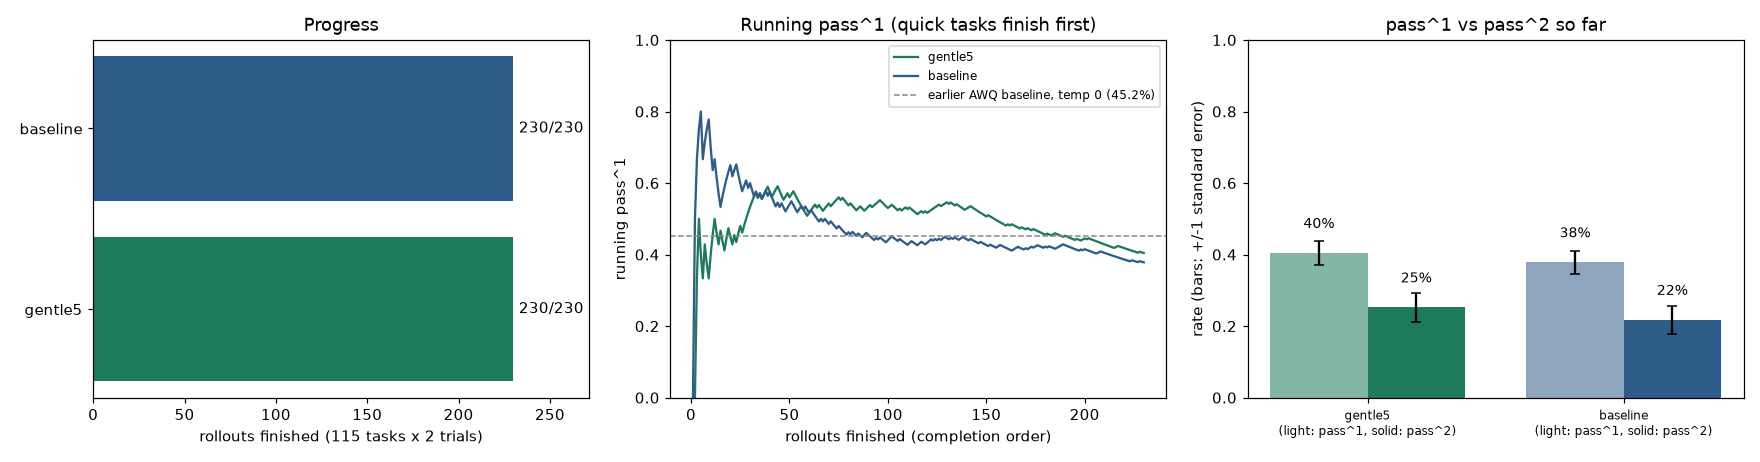

In [ ]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/passk_run.json"))
TOTAL = run["total_rollouts"]
colors = {"gentle5": "#1E7A5C", "baseline": "#2F5D8A"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for m in run["models"]:
    axes[0].barh([m["model"]], [m["done"]], color=colors[m["model"]])
    axes[0].text(m["done"] + 3, m["model"], f"{m['done']}/{TOTAL}", va="center")
axes[0].set_xlim(0, TOTAL * 1.18)
axes[0].set_xlabel("rollouts finished (115 tasks x 2 trials)")
axes[0].set_title("Progress")

for m in run["models"]:
    rows = sorted(m["rows"], key=lambda r: r["finished_at"])
    if rows:
        cum, ok = [], 0
        for i, r in enumerate(rows, 1):
            ok += r["reward"] >= 1
            cum.append(ok / i)
        axes[1].plot(range(1, len(rows) + 1), cum, color=colors[m["model"]], label=m["model"])
axes[1].axhline(run["reference_pass1_t0"], color="#888", ls="--", lw=1, label="earlier AWQ baseline, temp 0 (45.2%)")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("rollouts finished (completion order)")
axes[1].set_ylabel("running pass^1")
axes[1].set_title("Running pass^1 (quick tasks finish first)")
axes[1].legend(fontsize=8)

xs, w = 0, 0.38
labels = []
for i, m in enumerate(run["models"]):
    if m["pass1"] is None:
        continue
    axes[2].bar(i - w / 2, m["pass1"], w, yerr=m["pass1_se"], capsize=3, color=colors[m["model"]], alpha=0.55)
    axes[2].text(i - w / 2, m["pass1"] + 0.07, f"{m['pass1']:.0%}", ha="center", fontsize=9)
    if m["pass2"] is not None:
        axes[2].bar(i + w / 2, m["pass2"], w, yerr=m["pass2_se"], capsize=3, color=colors[m["model"]])
        axes[2].text(i + w / 2, m["pass2"] + 0.07, f"{m['pass2']:.0%}", ha="center", fontsize=9)
axes[2].set_xticks(range(len(run["models"])))
axes[2].set_xticklabels([m["model"] + "\n(light: pass^1, solid: pass^2)" for m in run["models"]], fontsize=8)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("rate (bars: +/-1 standard error)")
axes[2].set_title("pass^1 vs pass^2 so far")

plt.tight_layout()
plt.show()


In [43]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/passk_run.json"
LIVE = False  # True: keep redrawing this cell every 30 s until both runs are done (interrupt to stop)


def fmt_min(x):
    if x is None:
        return "estimating..."
    h, m = divmod(int(round(x)), 60)
    return f"{h} h {m:02d} min" if h else f"{m} min"


def pct(x, se=None):
    if x is None:
        return "-"
    return f"{x:.1%}" + (f" +/- {se:.1%}" if se is not None else "")


def render_html(run):
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='border-collapse:collapse;margin:6px 0 14px'><tr>{h}</tr>{b}</table>"
    rows = []
    for m in run["models"]:
        state = "finished" if m["finished"] else ("running" if m["running"] else "waiting")
        rows.append([html.escape(m["label"]), state, f"{m['done']} / {run['total_rollouts']}",
                     f"{m['tasks_both_done']} / {run['n_tasks']}", pct(m["pass1"], m["pass1_se"]),
                     pct(m["pass2"], m["pass2_se"]),
                     f"{m['consistency']:.2f}" if m["consistency"] is not None else "-",
                     f"{m['rollouts_per_min']:.2f}" if m.get("rollouts_per_min") else "-",
                     "done" if m["finished"] else fmt_min(m.get("eta_min")), m["errors"]])
    out = [f"<h4>pass^2 test: live status (data written {html.escape(run['last_update'])} = {html.escape(run['last_update_utc'])})</h4>"]
    out.append(table(["model", "state", "rollouts", "tasks with both trials", "pass^1", "pass^2", "consistency (pass^2 / pass^1)",
                      "rollouts/min", "time left", "errors"], rows))
    eta = run["eta"]
    if eta.get("both_min") is not None:
        out.append(f"<p><b>Estimated time to finish:</b> round 5 in about {fmt_min(eta['gentle5_min'])}; "
                   f"both runs in about {fmt_min(eta['both_min'])} (the control is assumed to take as long as round 5).</p>")
    else:
        lo, hi = eta["prior_per_model_min"]
        out.append(f"<p><b>Estimated time to finish:</b> the pace is not measured yet (needs about 10 finished rollouts); "
                   f"expect {lo}-{hi} min per model, so {lo * 2}-{hi * 2} min for both. Early finishers are the quick tasks, "
                   f"so the first estimates run optimistic.</p>")
    c = run.get("comparison")
    if c:
        out.append(f"<p><b>pass^2, round 5 vs control, on the {c['n_common']} tasks both have finished:</b> "
                   f"{c['gentle5_only']} tasks only round 5 passes twice, {c['baseline_only']} only the control does "
                   f"(paired test p = {c['p_value']:.2f}).</p>")
    out.append(f"<p style='opacity:.7'>Each task is run {run['trials']} times at temperature {run['temperature']}. pass^2 = share of tasks "
               f"where both trials pass; consistency = pass^2 / pass^1 on the same tasks (1.0 would mean fully repeatable). "
               f"Reference: the earlier un-tuned Qwen3-14B-AWQ full eval scored {run['reference_pass1_t0']:.1%} at temperature 0, one trial "
               f"(different setup, a rough guide only).</p>")
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if run["all_done"]:
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


model,state,rollouts,tasks with both trials,pass^1,pass^2,consistency (pass^2 / pass^1),rollouts/min,time left,errors
"gentle round 5 (combo-pool GRPO, lr 1e-6)",finished,230 / 230,115 / 115,40.4% +/- 3.2%,25.2% +/- 4.0%,0.62,3.02,done,0
starting adapter (control),finished,230 / 230,115 / 115,37.8% +/- 3.2%,21.7% +/- 3.8%,0.57,3.16,done,0


## Section 11: a 32B teacher on the hard combo tasks (stage 1 of distillation)

Plan: let Qwen3-32B-AWQ play every combo train task that the 14B does not reliably solve (up to 4 samples each, temperature 0.7;
a task stops being sampled once it has 2 passes), keep the passing conversations, and fine-tune the 14B on them. "Does not reliably
solve" comes from our earlier diagnostic of the 153 combo train tasks: 58 never solved and 56 solved sometimes (114 tasks, all
included); the 39 the 14B always solves are skipped. They run one after the other, never in parallel: first the 65 from the original
unsolved list (46 never + 19 sometimes), then 49 more (12 never + 37 sometimes). Stage 1 is the go/no-go check on the never-solved
tasks: if the 32B solves under about 30% of the 58 there is too little hard data to train on.

(The original list over-counted because 126 of the 422 first-run rollouts had no recorded task id.)

The cells below only read `full_run_results/teacher_run.json` (written with timestamps by `teacher/update_teacher_json.py`);
re-run them to redraw. Set `LIVE = True` in the status cell to have it redraw itself every 30 seconds.


In [102]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/teacher_run.json"
LIVE = False  # True: re-read the JSON and redraw every 30 s until the run finishes (interrupt to stop)


def fmt_min(x):
    if x is None:
        return "estimating..."
    h, m = divmod(int(round(x)), 60)
    return f"{h} h {m:02d} min" if h else f"{m} min"


def render_html(run):
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='border-collapse:collapse;margin:6px 0 14px'><tr>{h}</tr>{b}</table>"
    s, ts = run["summary"], run["timestamps"]
    out = [f"<h4>32B teacher run (JSON written {html.escape(run['updated'])} = {html.escape(run['updated_utc'])})</h4>"]
    verdict = "-"
    if s["tasks_with_all_trials"] >= 0.5 * s["n_tasks"] or run["stage"] == "finished":
        verdict = "GO" if s["solved_fraction"] >= s["go_no_go_threshold"] else "NO-GO (too little data)"
    out.append(table(["", ""], [
        ["stage", html.escape(run["stage"]) + ("" if run["pod_reachable"] else " (pod unreachable, showing last known state)")],
        ["rollouts", f"{s['rollouts_done']} run, up to {s['total_rollouts']} ({s['rollouts_passed']} passed, {s['errors']} errors, "
                     f"{s.get('rollouts_skipped', 0)} skipped because the task already had {s.get('stop_after_passes', 2)} passes)"],
        ["tasks solved at least once", f"{s['tasks_solved']} / {s['n_tasks']}; go/no-go on {s.get('go_no_go_basis', 'all tasks')}: {s['solved_fraction']:.0%} (threshold {s['go_no_go_threshold']:.0%})"],
        ["verdict (shown once half the hard tasks are complete)", verdict],
        ["pace", f"{s['rollouts_per_min']:.2f} rollouts/min" if s.get("rollouts_per_min") else "not measured yet (needs 10 finished rollouts)"],
        ["time left (upper bound: skipped trials shorten it)", "done" if run["stage"] == "finished" else fmt_min(s.get("eta_min"))],
    ]))
    out.append("<b>Timestamps</b>" + table(["event", "time (local)"], [
        [k.replace("_", " "), html.escape(ts.get(k, "-"))] for k in ("setup_seen", "setup_done", "vllm_ready", "rollouts_started", "teacher_done")]
        + [["last rollout finished", html.escape(run["rollout_finish_times"][-1]) if run["rollout_finish_times"] else "-"]]))
    g = run["groups_14b"]
    out.append("<b>By how the 14B did on these tasks in the earlier diagnostic</b>" + table(
        ["14B group", "tasks", "solved by the 32B", "rollouts passed / done"],
        [[k, g[k]["n_tasks"], f"{g[k]['solved']} ({g[k]['solved'] / g[k]['n_tasks']:.0%})" if g[k]["n_tasks"] else "-",
          f"{g[k]['rollouts_passed']} / {g[k]['rollouts_done']}"] for k in ("never", "mixed", "always")]))
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if run["stage"] == "finished":
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


,
stage,rollouts running
rollouts,"418 run, up to 456 (198 passed, 1 errors, 54 skipped because the task already had 2 passes)"
tasks solved at least once,86 / 114; go/no-go on tasks the 14B never solves: 60% (threshold 30%)
verdict (shown once half the hard tasks are complete),GO
pace,3.34 rollouts/min
time left (upper bound: skipped trials shorten it),0 min
event,time (local)
setup seen,2026-10-02T13:42:52+04:00
setup done,2026-10-02T13:50:11+04:00
vllm ready,2026-10-02T13:50:11+04:00


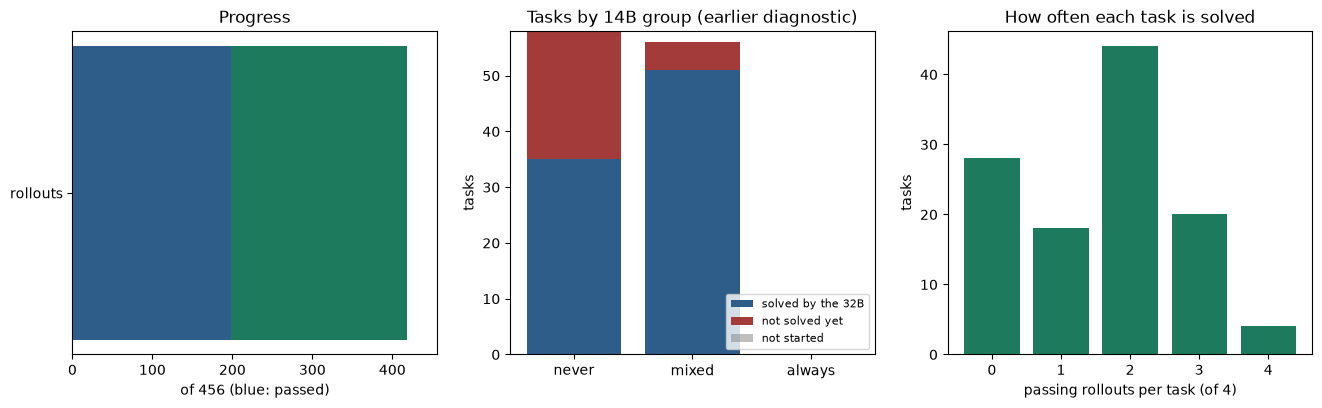

<Figure size 640x480 with 0 Axes>

In [103]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/teacher_run.json"))
s, g = run["summary"], run["groups_14b"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].barh(["rollouts"], [s["rollouts_done"]], color="#1E7A5C")
axes[0].barh(["rollouts"], [s["rollouts_passed"]], color="#2F5D8A")
axes[0].set_xlim(0, s["total_rollouts"])
axes[0].set_xlabel(f"of {s['total_rollouts']} (blue: passed)")
axes[0].set_title("Progress")

names = ["never", "mixed", "always"]
solved = [g[k]["solved"] for k in names]
unsolved = [g[k]["tasks_with_any_rollout"] - g[k]["solved"] for k in names]
pending = [g[k]["n_tasks"] - g[k]["tasks_with_any_rollout"] for k in names]
axes[1].bar(names, solved, color="#2F5D8A", label="solved by the 32B")
axes[1].bar(names, unsolved, bottom=solved, color="#A33B3B", label="not solved yet")
axes[1].bar(names, pending, bottom=[a + b for a, b in zip(solved, unsolved)], color="#8888", label="not started")
axes[1].set_ylabel("tasks")
axes[1].set_title("Tasks by 14B group (earlier diagnostic)")
axes[1].legend(fontsize=8)

counts = [sum(1 for p in run["per_task"] if p["n_done"] >= 1 and p["passes"] == k) for k in range(s["trials"] + 1)]
axes[2].bar([str(k) for k in range(s["trials"] + 1)], counts, color="#1E7A5C")
axes[2].set_xlabel("passing rollouts per task (of 4)")
axes[2].set_ylabel("tasks")
axes[2].set_title("How often each task is solved")

plt.show()
plt.tight_layout()


## Section 12: fine-tuning the 14B on the 32B teacher's passed conversations, then tau-bench tests (live)

Stage 2 and 3 of the distillation. The 32B teacher (Section 11) solved 86 of the 114 combo tasks the 14B does not reliably solve and
produced 180 passing conversations (60 from tasks the 14B never solves, 120 from ones it solves sometimes), about 17 agent turns each.
Each conversation becomes one training example per agent turn, laid out exactly as the model sees it at inference, with the 32B's
thinking kept (3,065 examples, one epoch, 4-bit LoRA rank 16, learning rate 5e-5, batch 8, loss on the agent's reply only).

This section has two parts, each with its own status cell and plots cell:
1. **Training**: the SFT run itself (loss, gradient norm, learning rate, checkpoints, timing).
2. **tau-bench evaluation**: the tests of the result, retail and airline (below).

**Retail test.** The new adapter takes the full 115-task retail test at temperature 0.7 (the setup of Section 10): first two trials per task,
then two more trials for both the new model and the starting adapter to cut the noise (so up to four per task). With several trials, **pass^1** is the
average pass rate and **pass^2** is the chance that two random trials of a task both pass (C(c,2) / C(n,2) for c passes in n trials, averaged over tasks;
with two trials it is "both pass").
Two baselines are shown next to it: the **earlier test** of the starting adapter from Section 10 (different pod and GPU), and a **re-run of
the starting adapter on the same pod, server and settings** as the new model, which removes the pod/GPU difference.

**Airline test.** After retail trials 3 and 4, the same two adapters (the new model, then the starting adapter) are run on the **airline** domain:
50 tasks (the only split airline has), two trials each at temperature 0.7, tool-calling agent with GPT-4o as the customer, 25 steps, so 100 rollouts
per model. The fine-tuning never saw airline conversations, so this checks whether the retail gain carries over to a different domain or the
model got worse elsewhere. The runs go one after the other on the same server (never in parallel), and at the retail pace (about 4-5 rollouts per minute) each model takes
roughly 20-25 minutes. The airline test was started once and paused after a few rollouts so the retail trials 3 and 4 could run first; it resumes
from the saved rollouts. The evaluation status cell shows the remaining steps with their estimated finish times.

Each pass rate over 115 retail tasks has a standard error of about 4 points (about 6 over the 50 airline tasks), so gaps under roughly
8 points should be read with care. The cells below only read `full_run_results/distill_run.json` (written with timestamps by
`teacher/update_distill_json.py`); re-run them to redraw. Set `LIVE = True` in a status cell to have it redraw itself every 30 seconds.


### Part 1: training (SFT of the 14B)

In [ ]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/distill_run.json"
LIVE = False  # True: re-read the JSON and redraw every 30 s until training is finished (interrupt to stop)


def fmt_min(x):
    if x is None:
        return "estimating..."
    h, m = divmod(int(round(x)), 60)
    return f"{h} h {m:02d} min" if h else f"{m} min"


def render_html(run):
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='border-collapse:collapse;margin:6px 0 14px'><tr>{h}</tr>{b}</table>"
    t, ev, d = run["training"], run["events_local"], run["data"]
    finished = "training_finished" in ev
    state = "finished" if finished else ("running" if run["stage"] == "training" else html.escape(run["stage"]))
    out = [f"<h4>Training (JSON written {html.escape(run['updated'])} = {html.escape(run['updated_utc'])})</h4>"]
    rows = [["state", state + ("" if run["pod_reachable"] else " (pod unreachable, showing last known state)")],
            ["data", f"{d['conversations']} passed conversations from the 32B teacher, {d['samples']} per-turn examples, {d['epochs']} epoch"],
            ["setup", "4-bit LoRA rank 16, learning rate 5e-5 (linear decay), batch 8 examples, loss on the agent's reply only"]]
    if t.get("steps_total"):
        rows.append(["progress", f"step {t['steps_done']} / {t['steps_total']} ({t['steps_done'] / t['steps_total']:.0%})"
                     + (f", {t['sec_per_step']:.0f} s per step" if t.get("sec_per_step") else "")])
        if t.get("loss_last10") is not None:
            rows.append(["loss", f"{t['loss_first10']:.3f} (first 10 steps) to {t['loss_last10']:.3f} (last 10); gradient norm max {max(t['grad_norm']):.2f}"])
        rows.append(["time", ("done in " + fmt_min(t.get("elapsed_min"))) if finished else f"{fmt_min(t.get('elapsed_min'))} so far, about {fmt_min(t.get('eta_min'))} left"])
        rows.append(["checkpoints on the pod", ", ".join(c for c in t["checkpoints"] if c.startswith(("step", "epoch"))) or "-"])
    out.append(table(["", ""], rows))
    keys = ("teacher_finished", "training_started", "training_finished")
    out.append("<b>Timestamps (local)</b>" + table(["event", "time"], [[k.replace("_", " "), html.escape(ev[k])] for k in keys if k in ev] or [["(none yet)", ""]]))
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if "training_finished" in run["events_local"] or run["stage"].startswith("failed"):
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


In [ ]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/distill_run.json"))
t = run["training"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))

ax = axes[0]
if t["loss"]:
    ax.plot(t["step_index"], t["loss"], color="#8888", lw=0.8, label="per step")
    w = 15
    if len(t["loss"]) >= w:
        ma = [sum(t["loss"][i - w:i]) / w for i in range(w, len(t["loss"]) + 1)]
        ax.plot(t["step_index"][w - 1:], ma, color="#1E7A5C", lw=2, label=f"{w}-step average")
    for c in t["checkpoints"]:
        if c.startswith("step-"):
            ax.axvline(int(c.split("-")[1]), color="#2F5D8A", ls=":", lw=1)
    ax.legend(fontsize=8)
ax.set_xlabel("optimizer step (8 examples each; dotted lines: saved checkpoints)")
ax.set_ylabel("loss on the agent's reply")
ax.set_title("Training loss" + (f" ({t['steps_done']}/{t['steps_total']} steps)" if t["steps_total"] else ""))

ax = axes[1]
if t["grad_norm"]:
    ax.plot(t["step_index"], t["grad_norm"], color="#A33B3B", lw=1)
    ax.set_ylabel("gradient norm", color="#A33B3B")
    ax2 = ax.twinx()
    ax2.plot(t["step_index"], t["lr"], color="#2F5D8A", lw=1)
    ax2.set_ylabel("learning rate", color="#2F5D8A")
ax.set_xlabel("optimizer step")
ax.set_title("Gradient norm and learning rate")

ax = axes[2]
if t["tokens"]:
    ax.bar(t["step_index"], t["tokens"], color="#8888", width=1.0)
ax.set_xlabel("optimizer step")
ax.set_ylabel("completion tokens in the step")
ax.set_title("Size of each training step")

plt.tight_layout()
plt.show()


### Part 2: tau-bench evaluation (retail and airline)

In [27]:
import datetime, html, json, time
from IPython.display import HTML, clear_output, display

RUN = "full_run_results/distill_run.json"
LIVE = False  # True: re-read the JSON and redraw every 30 s until all tests are done (interrupt to stop)


def fmt_min(x):
    if x is None:
        return "estimating..."
    h, m = divmod(int(round(x)), 60)
    return f"{h} h {m:02d} min" if h else f"{m} min"


def pct(x, se=None):
    return "-" if x is None else f"{x:.1%}" + (f" +/- {se:.1%}" if se is not None else "")


def render_html(run):
    td = "border:1px solid #8886;padding:3px 10px;text-align:left"
    def table(head, body):
        h = "".join(f"<th style='{td}'>{c}</th>" for c in head)
        b = "".join("<tr>" + "".join(f"<td style='{td}'>{c}</td>" for c in row) + "</tr>" for row in body)
        return f"<table style='border-collapse:collapse;margin:6px 0 14px'><tr>{h}</tr>{b}</table>"
    _plan = {st["proc"]: st for st in (run.get("plan") or {}).get("steps", [])}
    def plan_note(proc, d):
        # time left comes from the plan (pace of the process running now), so it matches the "now / next" table
        st = _plan.get(proc)
        if not st or st["remaining"] <= 0 or run["stage"] == "finished":
            return ""
        return (f", {st['remaining']} left, about {fmt_min(st['done_in_min'])}, done at about {st['done_at']}" if st["running"]
                else f", waiting, {st['remaining']} to do, done at about {st['done_at']}")
    e, r2, b, ev = run["eval"], run.get("rerun") or {}, run["baseline"], run["events_local"]
    air = run.get("airline") or {}
    out = [f"<h4>tau-bench evaluation (JSON written {html.escape(run['updated'])} = {html.escape(run['updated_utc'])})</h4>"]
    rows = [["stage", html.escape(run["stage"]) + ("" if run["pod_reachable"] else " (pod unreachable, showing last known state)")]]
    if e["rollouts_done"]:
        rows.append(["retail test, new model", f"{e['rollouts_done']} / {e['rollouts_total']} rollouts, {e['errors']} errors" + plan_note("distilled", e)])
    if r2.get("rollouts_done") is not None:
        rows.append(["retail test, starting adapter re-run (same pod)", f"{r2.get('rollouts_done', 0)} / {r2.get('rollouts_total', 460)} rollouts, {r2.get('errors', 0)} errors" + plan_note("baseline2", r2)])
    for key, label in (("new", "airline test, new model"), ("base", "airline test, starting adapter")):
        a_ = air.get(key) or {}
        if a_.get("rollouts_done") or run.get("airline_eta"):
            rows.append([label, f"{a_.get('rollouts_done', 0)} / {a_.get('rollouts_total', 100)} rollouts, {a_.get('errors', 0)} errors"])
    plan = run.get("plan") or {}
    if plan.get("steps"):
        for st in plan["steps"]:
            rows.append([("now: " if st["running"] else "next: ") + st["step"],
                         f"{st['remaining']} rollouts left, about {fmt_min(st['minutes'])}, done at about {st['done_at']}"])
        rows.append(["everything done at about", f"{plan['done_at']} local (in about {fmt_min(plan['total_min'])}; pace {plan['pace_used']:.1f} rollouts per minute, "
                     + ("measured now" if plan.get("pace_measured") else "from the earlier retail runs") + ")"])
    out.append(table(["", ""], rows))
    if e["rollouts_done"]:
        bs = lambda k: b.get(k) if b else None
        cons = lambda x: f"{x:.2f}" if x else "-"
        out.append("<b>Retail test: new model vs the starting adapter</b>" + table(
            ["", "new model (SFT on the teacher)", "starting adapter, re-run on the same pod", "starting adapter, earlier test (other pod)"],
            [["pass^1", pct(e["pass1"], e.get("pass1_se")), pct(r2.get("pass1"), r2.get("pass1_se")), pct(bs("pass1"), bs("pass1_se"))],
             ["pass^2 (two random trials both pass)", pct(e["pass2"], e.get("pass2_se")), pct(r2.get("pass2"), r2.get("pass2_se")), pct(bs("pass2"), bs("pass2_se"))],
             ["pass^3 (three random trials all pass)", pct(e.get("pass3"), e.get("pass3_se")), pct(r2.get("pass3"), r2.get("pass3_se")), pct(bs("pass3"), bs("pass3_se"))],
             ["pass^4 (all four trials pass)", pct(e.get("pass4"), e.get("pass4_se")), pct(r2.get("pass4"), r2.get("pass4_se")), pct(bs("pass4"), bs("pass4_se"))],
             ["tasks with 3+ / 4 trials done", f"{e.get('tasks_for_pass3', 0)} / {e.get('tasks_for_pass4', 0)}", f"{r2.get('tasks_for_pass3', 0)} / {r2.get('tasks_for_pass4', 0)}", "-"],
             ["consistency (pass^2 / pass^1)", cons(e.get("consistency")), cons(r2.get("consistency")), cons(bs("consistency"))]]))
        tr_ = lambda src: (src or {}).get("by_trial") or {}
        ks = sorted({int(k) for src in (e, r2, b) for k in tr_(src)})
        if ks:
            def tcell(src, k):
                x = tr_(src).get(str(k))
                return "-" if not x or not x["done"] else f"{x['pass_rate']:.1%} ({x['passed']}/{x['done']})"
            rows_t = [[f"trial {k + 1}" + (" (second half)" if k >= 2 else ""), tcell(e, k), tcell(r2, k), tcell(b, k)] for k in ks]
            rows_t.append(["all trials", f"{e['pass1']:.1%} ({e['passed']}/{e['rollouts_done']})" if e.get("pass1") is not None else "-",
                           f"{r2['pass1']:.1%} ({r2['passed']}/{r2['rollouts_done']})" if r2.get("pass1") is not None else "-",
                           f"{b['pass1']:.1%}" if b and b.get("pass1") is not None else "-"])
            out.append("<b>Retail pass rate by trial (each trial = one attempt at all 115 tasks; passed / rollouts done)</b>" + table(
                ["", "new model", "starting adapter, re-run (same pod)", "starting adapter, earlier test"], rows_t))
        g = run.get("groups") or {}
        if g.get("new"):
            def cell(src, kind, k):
                x = (g.get(src) or {}).get(kind)
                return "-" if not x or x.get(k) is None else f"{x[k]:.1%}"
            out.append("<b>Retail by task type (64 combo tasks, 51 others)</b>" + table(
                ["", "new", "re-run (same pod)", "earlier test"],
                [[f"{kind} tasks, {k.replace('pass', 'pass^')}", cell("new", kind, k), cell("rerun", kind, k), cell("earlier", kind, k)]
                 for kind in ("combo", "other") for k in ("pass1", "pass2", "pass3", "pass4")]))
        c = run.get("comparisons") or {}
        lines = []
        for key, label in (("new_vs_rerun", "new model vs re-run on the same pod"), ("new_vs_earlier", "new model vs the earlier test")):
            if c.get(key):
                x = c[key]
                lines.append(f"{label}: pass^2 is higher for the new model on {x['new_only']} tasks and higher for the baseline on {x['other_only']} "
                             f"({x.get('ties', 0)} tied; sign test on {x['n_common']} tasks, p = {x['p_value']:.3f})")
        if lines:
            out.append("<p><b>Retail pass^2 comparisons per task</b><br>" + "<br>".join(lines) + "</p>")
    an, ab = air.get("new") or {}, air.get("base") or {}
    if an.get("pass1") is not None or ab.get("pass1") is not None:
        cons_ = lambda x: f"{x:.2f}" if x else "-"
        out.append("<b>Airline test (50 tasks, never trained on): new model vs the starting adapter</b>" + table(
            ["", "new model", "starting adapter"],
            [["pass^1", pct(an.get("pass1"), an.get("pass1_se")), pct(ab.get("pass1"), ab.get("pass1_se"))],
             ["pass^2 (two random trials both pass)", pct(an.get("pass2"), an.get("pass2_se")), pct(ab.get("pass2"), ab.get("pass2_se"))],
             ["consistency (pass^2 / pass^1)", cons_(an.get("consistency")), cons_(ab.get("consistency"))]]))
        at_ = lambda src, k: ((src or {}).get("by_trial") or {}).get(str(k))
        akeys = sorted({int(k) for src in (an, ab) for k in ((src or {}).get("by_trial") or {})})
        if akeys:
            fmt_ = lambda x: "-" if not x or not x["done"] else f"{x['pass_rate']:.1%} ({x['passed']}/{x['done']})"
            out.append("<b>Airline pass rate by trial (passed / rollouts done)</b>" + table(
                ["", "new model", "starting adapter"], [[f"trial {k + 1}", fmt_(at_(an, k)), fmt_(at_(ab, k))] for k in akeys]))
        ac = air.get("comparison")
        if ac:
            out.append(f"<p>Airline pass^2 per task: higher for the new model on {ac['new_only']} tasks, higher for the starting adapter on {ac['other_only']} "
                       f"({ac.get('ties', 0)} tied; sign test on {ac['n_common']} tasks, p = {ac['p_value']:.3f})</p>")
    keys = ("eval_started", "rerun_finished", "extra_trials_started", "extra_new_finished", "extra_base_finished", "airline_new_finished", "airline_finished", "pipeline_done")
    out.append("<b>Timestamps (local)</b>" + table(["event", "time"], [[k.replace("_", " "), html.escape(ev[k])] for k in keys if k in ev] or [["(none yet)", ""]]))
    return "".join(out)


# --- run ---
if LIVE:
    while True:
        run = json.load(open(RUN))
        clear_output(wait=True)
        display(HTML(render_html(run)))
        if run["stage"] == "finished" or run["stage"].startswith("failed"):
            break
        time.sleep(30)
else:
    display(HTML(render_html(json.load(open(RUN)))))


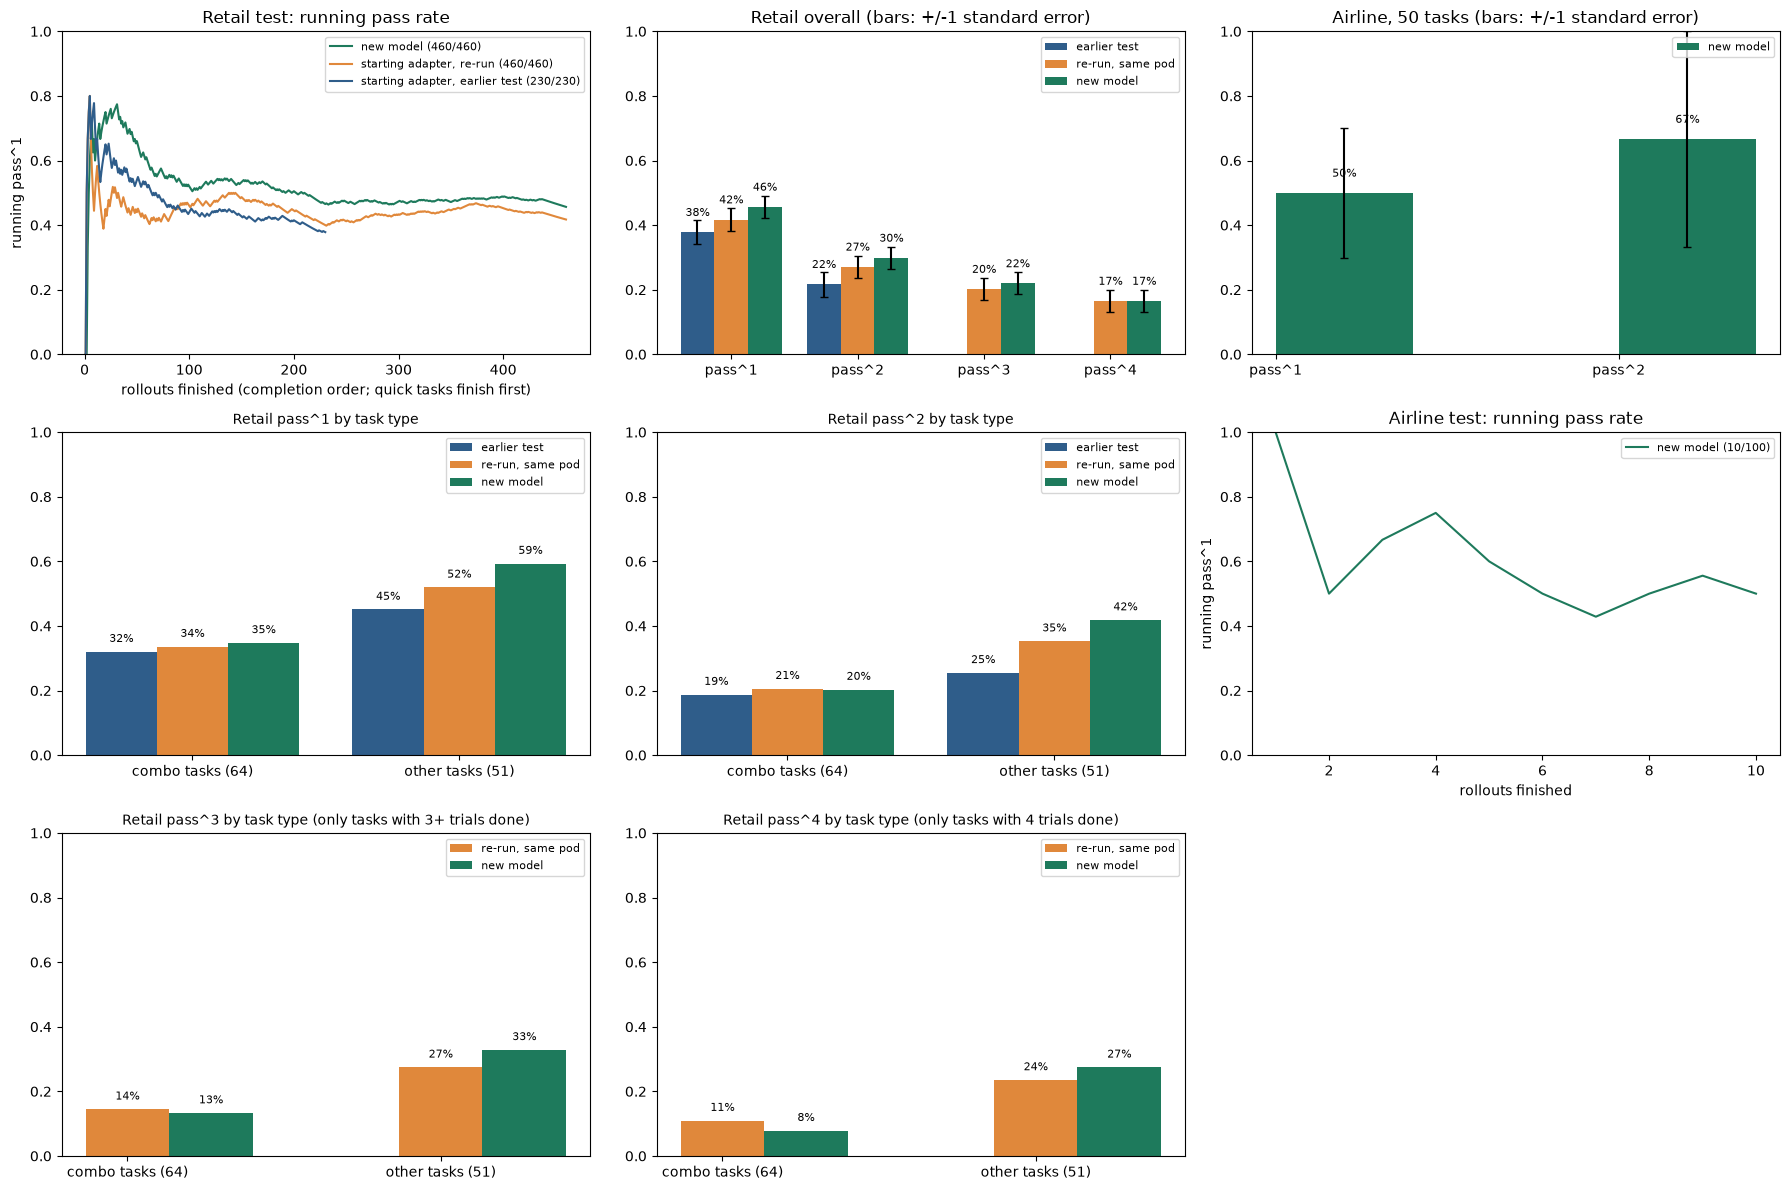

In [28]:
import json
import matplotlib.pyplot as plt

run = json.load(open("full_run_results/distill_run.json"))
e, r2, b = run["eval"], run.get("rerun") or {}, run["baseline"]
g = run.get("groups") or {}
air = run.get("airline") or {}
an, ab = air.get("new") or {}, air.get("base") or {}
C_NEW, C_RERUN, C_OLD = "#1E7A5C", "#E0883B", "#2F5D8A"
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# retail: running pass^1, all runs on the SAME axes
ax = axes[0][0]
if e["running_pass1"]:
    ax.plot(range(1, len(e["running_pass1"]) + 1), e["running_pass1"], color=C_NEW, label=f"new model ({e['rollouts_done']}/{e['rollouts_total']})")
if r2.get("running_pass1"):
    ax.plot(range(1, len(r2["running_pass1"]) + 1), r2["running_pass1"], color=C_RERUN, label=f"starting adapter, re-run ({r2['rollouts_done']}/{r2['rollouts_total']})")
if b and b.get("running_pass1"):
    ax.plot(range(1, len(b["running_pass1"]) + 1), b["running_pass1"], color=C_OLD, label=f"starting adapter, earlier test ({len(b['running_pass1'])}/230)")
elif b and b.get("pass1") is not None:
    ax.axhline(b["pass1"], color=C_OLD, ls="--", lw=1, label="starting adapter, earlier test (final)")
ax.set_ylim(0, 1)
ax.set_xlabel("rollouts finished (completion order; quick tasks finish first)")
ax.set_ylabel("running pass^1")
ax.set_title("Retail test: running pass rate")
ax.legend(fontsize=8)

# retail: overall bars
ax = axes[0][1]
sources = [("earlier test", C_OLD, b or {}), ("re-run, same pod", C_RERUN, r2), ("new model", C_NEW, e)]
shown = [(n, c, d) for n, c, d in sources if d.get("pass1") is not None]
if shown:
    w = 0.8 / len(shown)
    for j, (n, c, d) in enumerate(shown):
        for i, k in enumerate(("pass1", "pass2", "pass3", "pass4")):
            x = i - 0.4 + w * (j + 0.5)
            if d.get(k) is not None:
                ax.bar(x, d[k], w, yerr=d.get(k + "_se"), capsize=3, color=c, label=n if i == 0 else None)
                ax.text(x, d[k] + 0.05, f"{d[k]:.0%}", ha="center", fontsize=8)
    ax.set_xticks([0, 1, 2, 3]); ax.set_xticklabels(["pass^1", "pass^2", "pass^3", "pass^4"])
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "no retail test results yet", ha="center", va="center"); ax.set_axis_off()
ax.set_ylim(0, 1)
ax.set_title("Retail overall (bars: +/-1 standard error)")

# airline: bars
ax = axes[0][2]
if an.get("pass1") is not None or ab.get("pass1") is not None:
    for j, (n, c, d) in enumerate((("starting adapter", C_OLD, ab), ("new model", C_NEW, an))):
        for i, k in enumerate(("pass1", "pass2")):
            x = i - 0.4 + 0.4 * (j + 0.5)
            if d.get(k) is not None:
                ax.bar(x, d[k], 0.4, yerr=d.get(k + "_se"), capsize=3, color=c, label=n if i == 0 else None)
                ax.text(x, d[k] + 0.05, f"{d[k]:.0%}", ha="center", fontsize=8)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pass^1", "pass^2"])
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "airline test not started yet", ha="center", va="center"); ax.set_axis_off()
ax.set_ylim(0, 1)
ax.set_title("Airline, 50 tasks (bars: +/-1 standard error)")

# retail by task type
for ax, k, title in ((axes[1][0], "pass1", "Retail pass^1 by task type"), (axes[1][1], "pass2", "Retail pass^2 by task type"),
                     (axes[2][0], "pass3", "Retail pass^3 by task type (only tasks with 3+ trials done)"), (axes[2][1], "pass4", "Retail pass^4 by task type (only tasks with 4 trials done)")):
    srcs = [(n, c, g.get(key)) for n, c, key in (("earlier test", C_OLD, "earlier"), ("re-run, same pod", C_RERUN, "rerun"), ("new model", C_NEW, "new")) if g.get(key)]
    if srcs:
        w = 0.8 / len(srcs)
        for j, (n, c, d) in enumerate(srcs):
            for i, kind in enumerate(("combo", "other")):
                v = d[kind][k]
                if v is not None:
                    x = i - 0.4 + w * (j + 0.5)
                    ax.bar(x, v, w, color=c, label=n if i == 0 else None)
                    ax.text(x, v + 0.03, f"{v:.0%}", ha="center", fontsize=8)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["combo tasks (64)", "other tasks (51)"])
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "no results yet", ha="center", va="center"); ax.set_axis_off()
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)

# airline running pass^1
ax = axes[1][2]
for n, c, d in (("new model", C_NEW, an), ("starting adapter", C_OLD, ab)):
    if d.get("running_pass1"):
        ax.plot(range(1, len(d["running_pass1"]) + 1), d["running_pass1"], color=c, label=f"{n} ({d['rollouts_done']}/100)")
ax.set_ylim(0, 1)
ax.set_xlabel("rollouts finished")
ax.set_ylabel("running pass^1")
ax.set_title("Airline test: running pass rate")
if ax.get_legend_handles_labels()[0]:
    ax.legend(fontsize=8)

axes[2][2].set_axis_off()
plt.tight_layout()
plt.show()
